In [1]:
#!/usr/bin/env python
# coding: utf-8

# =============================================================================
# 导入库，设置绘图参数，加载数据
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pickle
import json
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

Path('figures/model_plots').mkdir(parents=True, exist_ok=True)

sns.set_context("paper")
sns.set_palette('muted')

ss   = 10
sss  = 8
ssss = 6

matplotlib.rcParams['figure.figsize']   = (3.2, 2.8)
matplotlib.rcParams['figure.dpi']       = 600
matplotlib.rcParams['font.sans-serif']  = ['Arial']
matplotlib.rcParams['font.family']      = 'sans-serif'
matplotlib.rcParams['font.style']       = 'normal'
matplotlib.rcParams['font.weight']      = 'bold'
matplotlib.rcParams['axes.labelweight'] = 'bold'
matplotlib.rcParams['axes.titlesize']   = sss
matplotlib.rcParams['legend.fontsize']  = ss
matplotlib.rcParams['axes.labelsize']   = ss
matplotlib.rcParams['xtick.labelsize']  = ss
matplotlib.rcParams['ytick.labelsize']  = ss
matplotlib.rcParams['axes.linewidth']   = 0.6
matplotlib.rcParams['lines.linewidth']  = 1.0
matplotlib.rcParams['axes.grid']        = False

scatter_s      = 20
ref_line_color = ['#4d4d4d', 'red']
ref_line_size  = 0.8

# 加载分类评分和对比数据
df_classification           = pd.read_csv('models/svr/classification_scores.csv')
df_classification_corrected = pd.read_csv('models/svr/classification_scores_corrected.csv')
df_comparison               = pd.read_csv('models/svr/correction_comparison.csv')

# 加载各折预测数据（校正前/后）
df_train_all = pd.concat(
    [pd.read_csv(f'models/svr/fold_{i}_train_predictions.csv') for i in range(1, 6)],
    ignore_index=True)
df_test_all = pd.concat(
    [pd.read_csv(f'models/svr/fold_{i}_test_predictions.csv') for i in range(1, 6)],
    ignore_index=True)
df_train_all_corrected = pd.concat(
    [pd.read_csv(f'models/svr/fold_{i}_train_predictions_corrected.csv') for i in range(1, 6)],
    ignore_index=True)
df_test_all_corrected = pd.concat(
    [pd.read_csv(f'models/svr/fold_{i}_test_predictions_corrected.csv') for i in range(1, 6)],
    ignore_index=True)

with open('models/svr/svr_results.json', 'r') as f:
    results_dict = json.load(f)
with open('models/svr/svr_final_model.pkl', 'rb') as f:
    model_package = pickle.load(f)

EDGE_THRESHOLD   = model_package['edge_threshold']
ATOM_TYPE_LABELS = model_package['atom_type_labels']
train_averaged   = results_dict['cv_results']['train']
test_averaged    = results_dict['cv_results']['test']

# 提取每折整体性能
folds      = [1, 2, 3, 4, 5]
df_numeric = df_classification[df_classification['fold'].isin(folds)]

train_maes, test_maes   = [], []
train_rmses, test_rmses = [], []
train_r2s, test_r2s     = [], []

for fold_num in folds:
    fd = df_numeric[df_numeric['fold'] == fold_num]
    train_maes.append( fd[(fd['dataset']=='train') & (fd['category']=='overall')]['mae'].values[0])
    test_maes.append(  fd[(fd['dataset']=='test')  & (fd['category']=='overall')]['mae'].values[0])
    train_rmses.append(fd[(fd['dataset']=='train') & (fd['category']=='overall')]['rmse'].values[0])
    test_rmses.append( fd[(fd['dataset']=='test')  & (fd['category']=='overall')]['rmse'].values[0])
    train_r2s.append(  fd[(fd['dataset']=='train') & (fd['category']=='overall')]['r2'].values[0])
    test_r2s.append(   fd[(fd['dataset']=='test')  & (fd['category']=='overall')]['r2'].values[0])



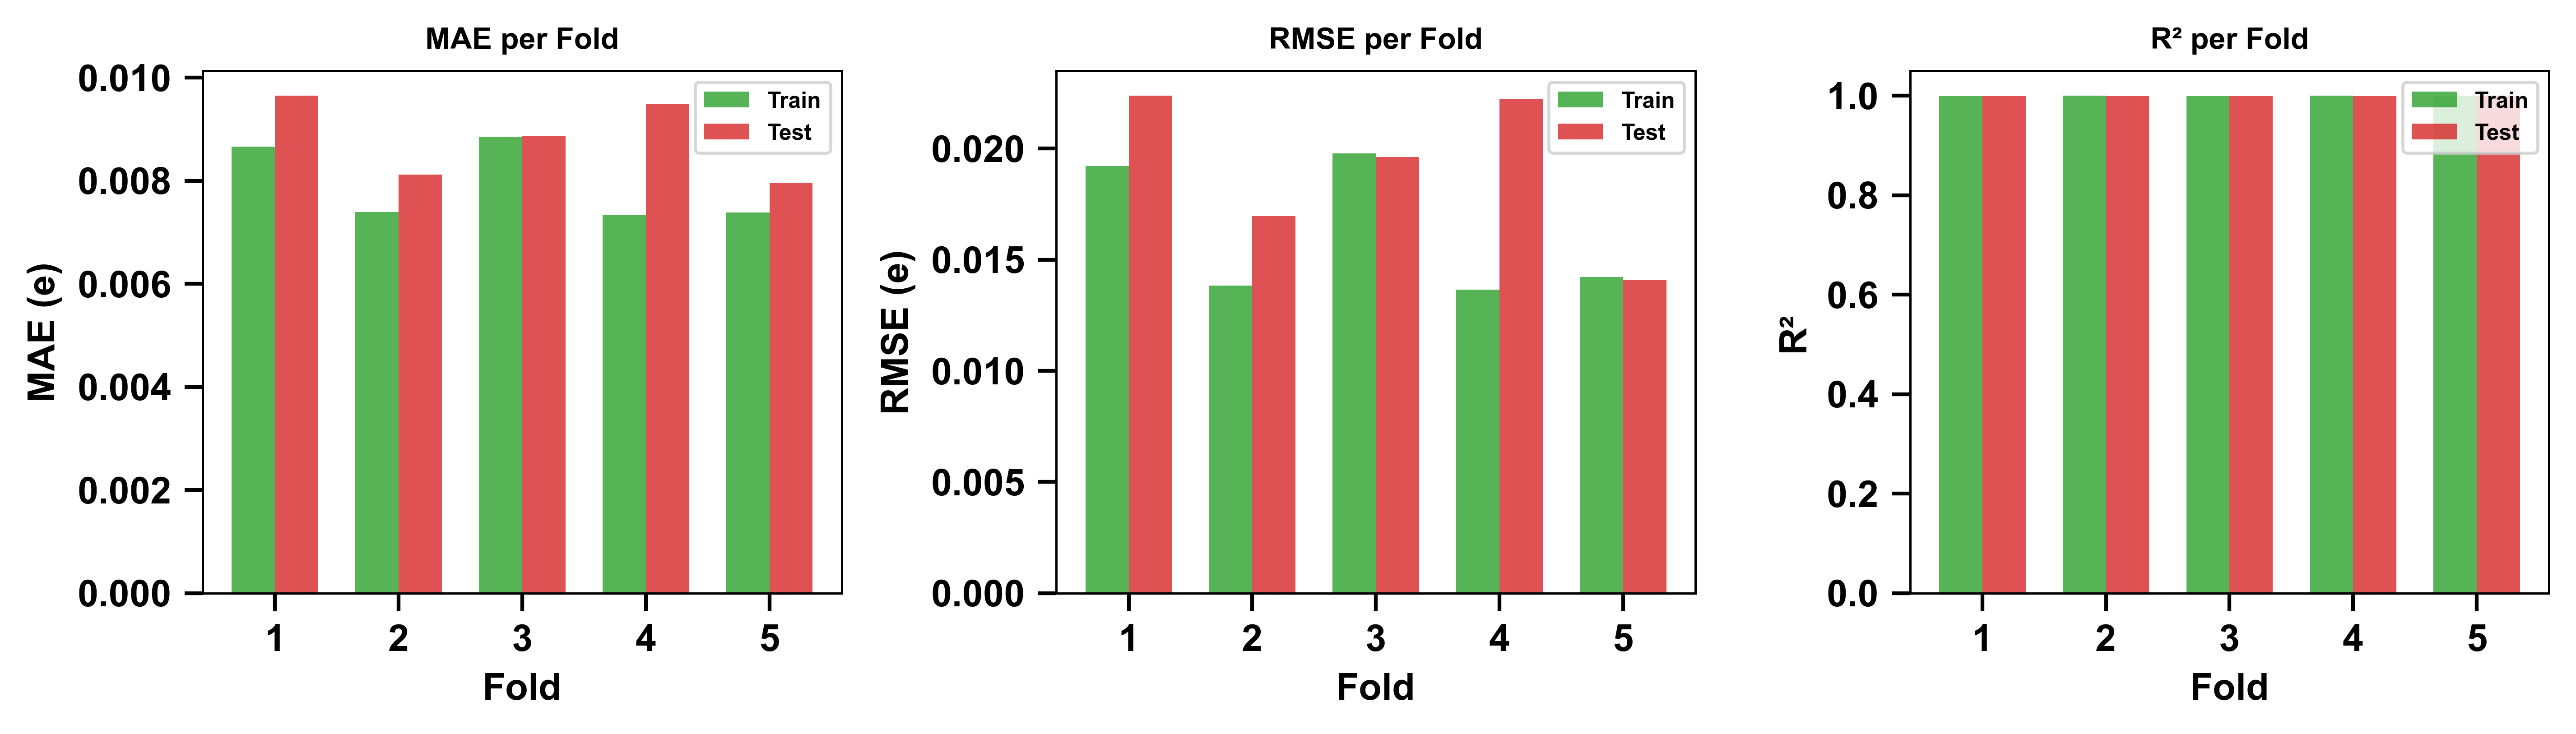

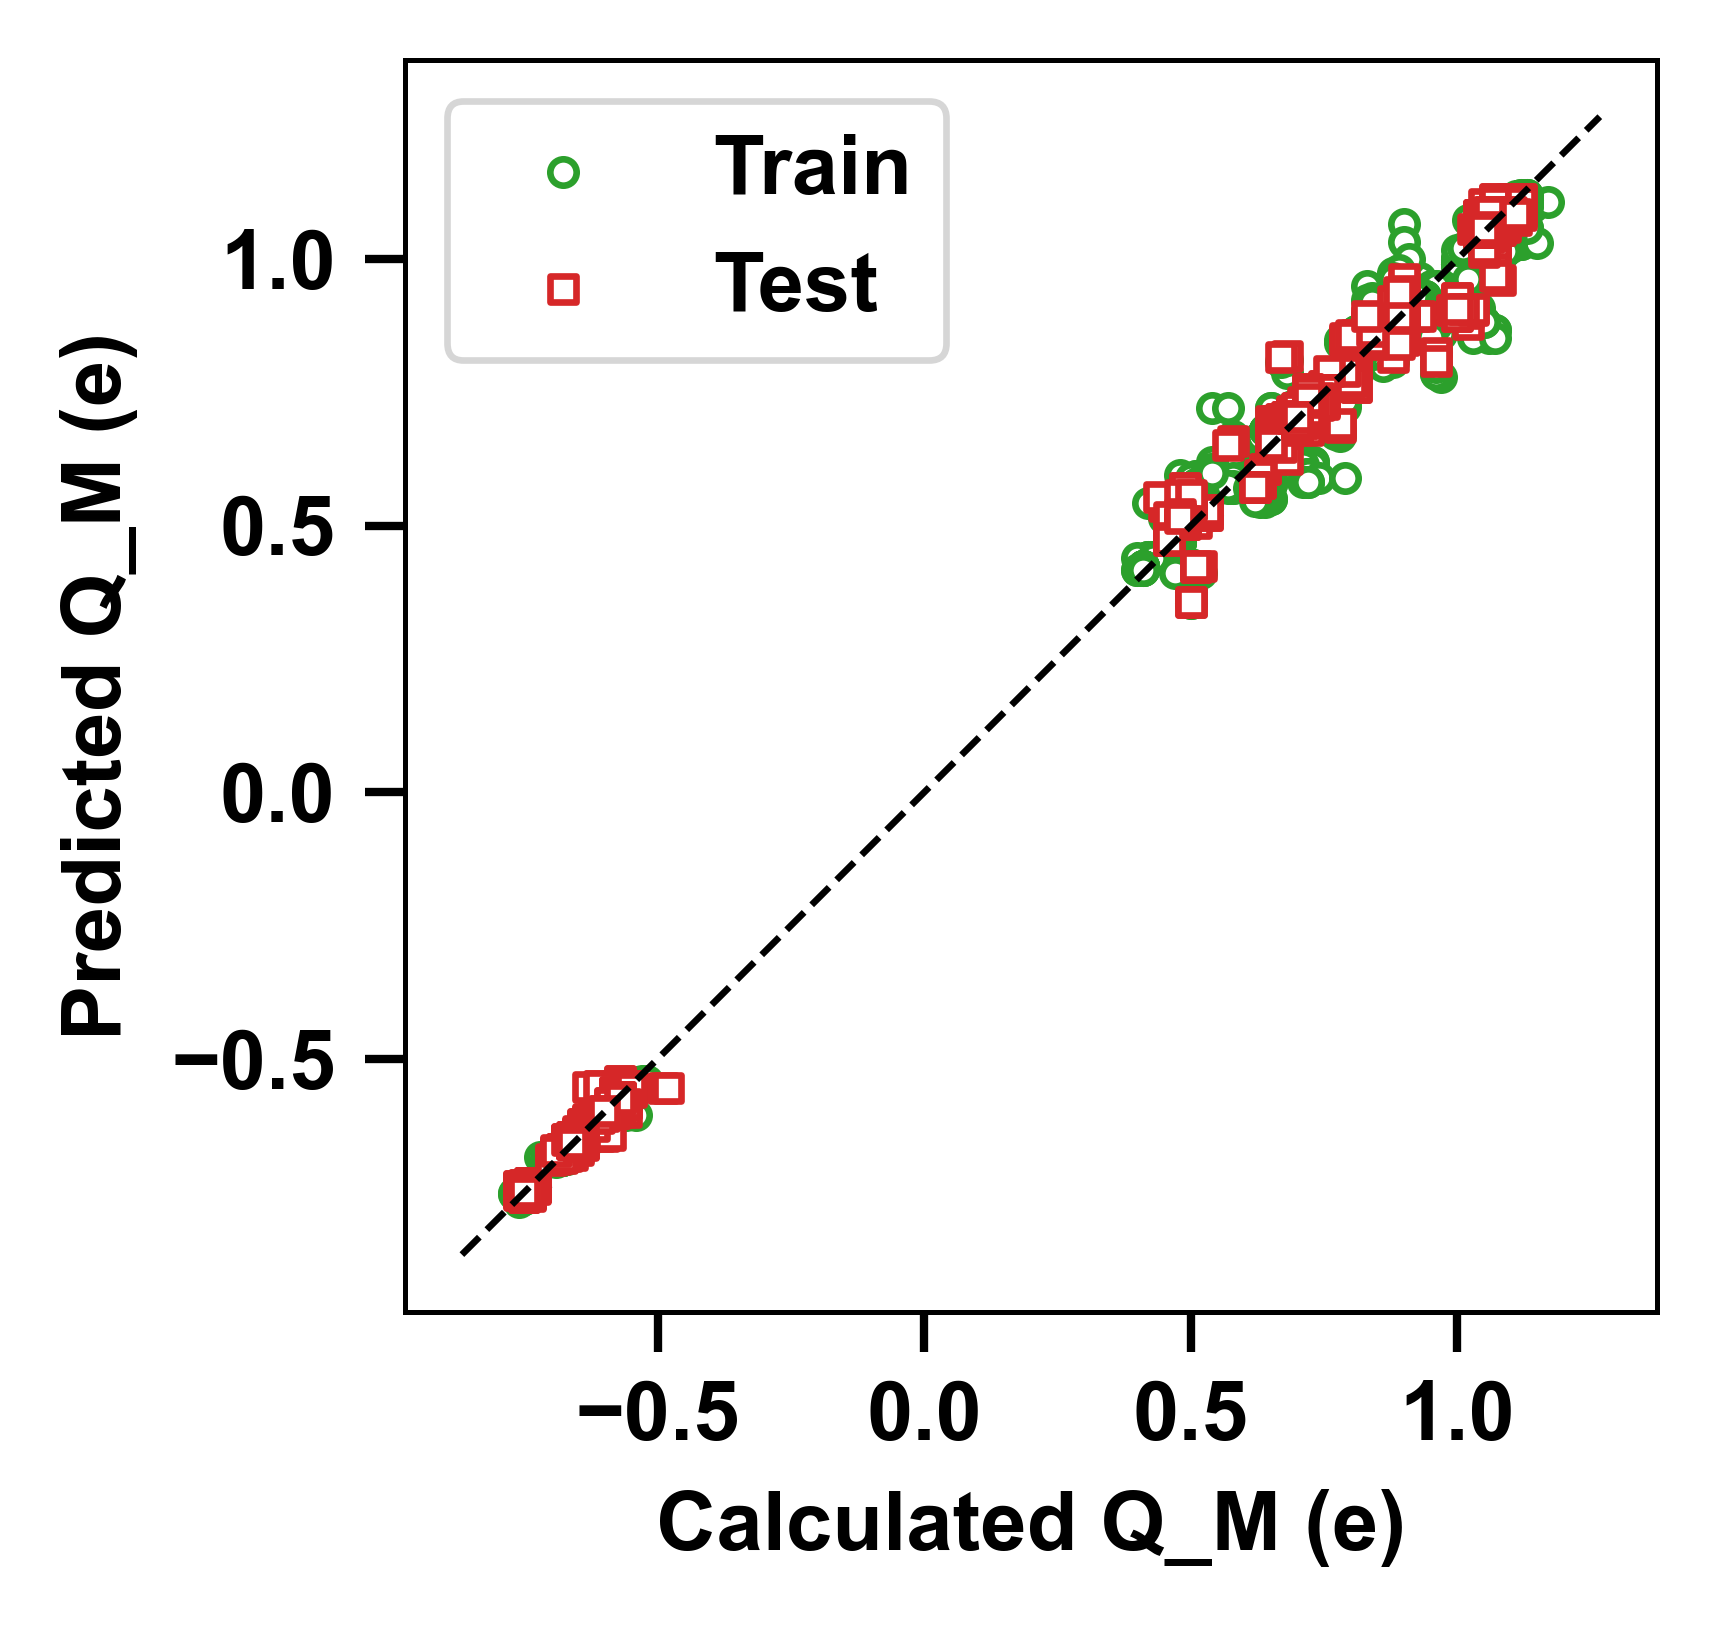

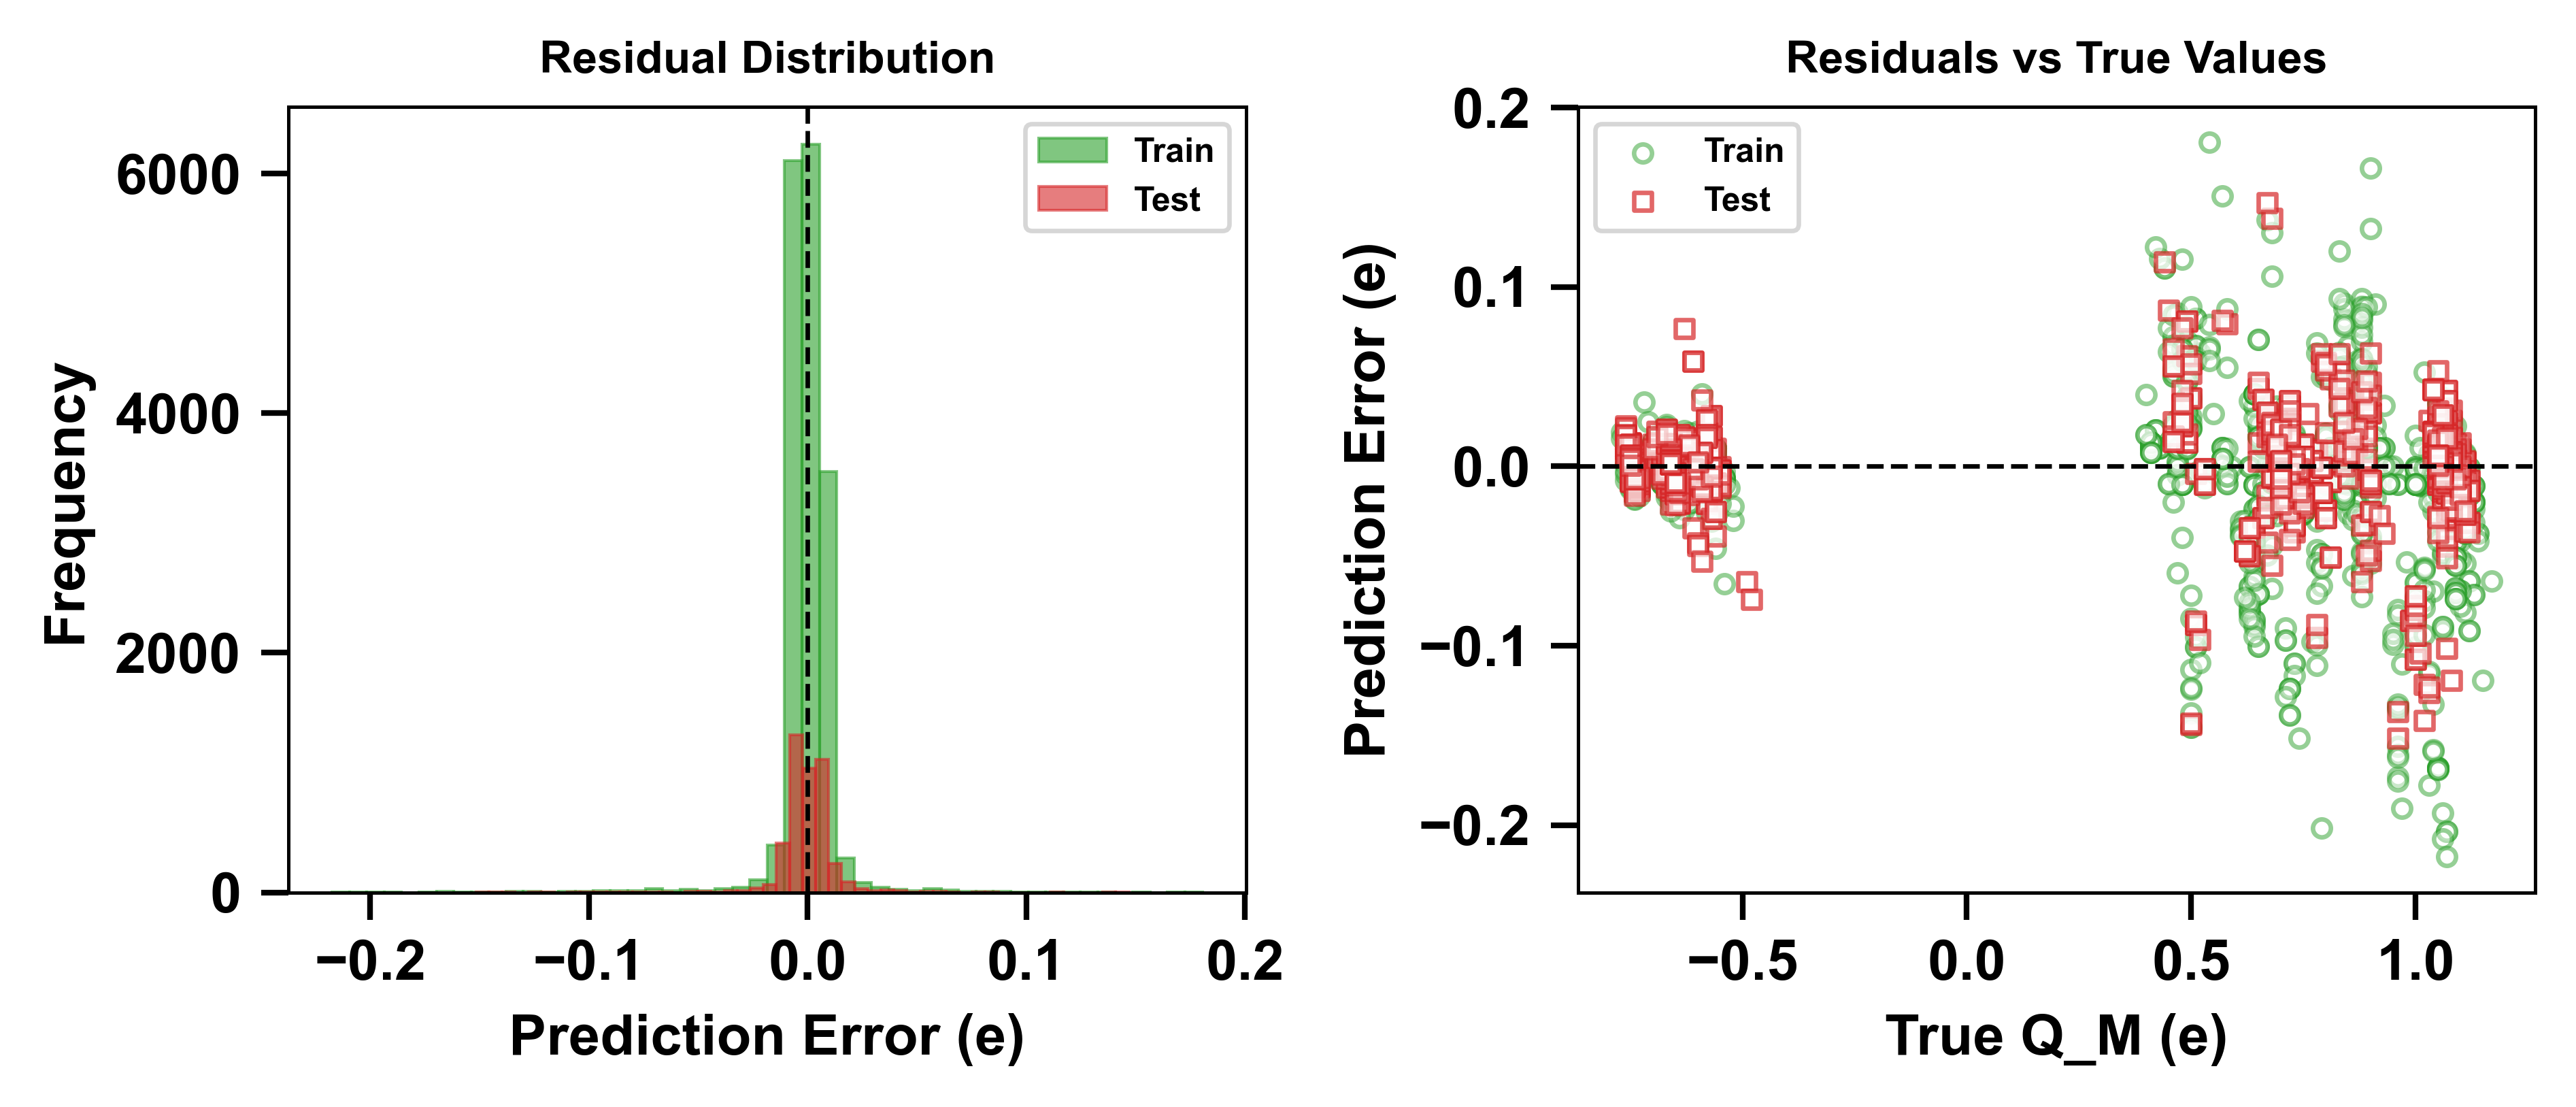

In [2]:
# =============================================================================
# 各折性能对比，预测vs实际散点图，残差分析
# =============================================================================

# 各折性能对比（MAE / RMSE / R²）
fig, axes = plt.subplots(1, 3, figsize=(9.6, 2.8))
x     = np.arange(1, 6)
width = 0.35

for ax, train_vals, test_vals, title, ylabel in zip(
    axes,
    [train_maes, train_rmses, train_r2s],
    [test_maes,  test_rmses,  test_r2s],
    ['MAE', 'RMSE', 'R²'],
    ['MAE (e)', 'RMSE (e)', 'R²']
):
    ax.bar(x - width/2, train_vals, width, label='Train', alpha=0.8, color='tab:green')
    ax.bar(x + width/2, test_vals,  width, label='Test',  alpha=0.8, color='tab:red')
    ax.set_xlabel('Fold', fontsize=ss)
    ax.set_ylabel(ylabel, fontsize=ss)
    ax.set_title(f'{title} per Fold', fontsize=sss, weight='bold')
    ax.set_xticks(x)
    ax.legend(fontsize=ssss)

plt.tight_layout()
plt.savefig('figures/model_plots/svr_01_cv_performance.png', dpi=600, bbox_inches='tight')
plt.show()

# 预测vs实际散点图（测试集MAE最小的折叠）
best_fold_num = folds[int(np.argmin(test_maes))]

df_train_best = df_train_all[df_train_all['fold'] == best_fold_num]
df_test_best  = df_test_all[ df_test_all['fold']  == best_fold_num]

y_train_true = df_train_best['y_true'].values;  y_train_pred = df_train_best['y_pred'].values
y_test_true  = df_test_best['y_true'].values;   y_test_pred  = df_test_best['y_pred'].values

fig, ax = plt.subplots(figsize=(3.2, 2.8))

ax.scatter(y_train_true, y_train_pred, s=10, marker='o',
           color='w', edgecolors='tab:green', linewidths=0.8, label='Train')
ax.scatter(y_test_true,  y_test_pred,  s=10, marker='s',
           color='w', edgecolors='tab:red',   linewidths=0.8, label='Test')

all_vals = np.concatenate([y_train_true, y_train_pred, y_test_true, y_test_pred])
vmin, vmax = all_vals.min(), all_vals.max()
margin = (vmax - vmin) * 0.05
ax.plot([vmin-margin, vmax+margin], [vmin-margin, vmax+margin],
        'k--', linewidth=ref_line_size)

ax.set_xlabel('Calculated Q_M (e)')
ax.set_ylabel('Predicted Q_M (e)')
ax.legend(frameon=True, loc='upper left')
ax.set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.savefig('figures/model_plots/svr_02_pred_vs_true.png', dpi=600, bbox_inches='tight')
plt.savefig('figures/model_plots/svr_02_pred_vs_true.pdf', dpi=600, bbox_inches='tight')
plt.show()

# 残差分析
train_errors = y_train_pred - y_train_true
test_errors  = y_test_pred  - y_test_true

fig, axes = plt.subplots(1, 2, figsize=(6.4, 2.8))

axes[0].hist(train_errors, bins=50, alpha=0.6, color='tab:green',
             edgecolor='tab:green', linewidth=0.5, label='Train')
axes[0].hist(test_errors,  bins=50, alpha=0.6, color='tab:red',
             edgecolor='tab:red',   linewidth=0.5, label='Test')
axes[0].axvline(0, color='black', linestyle='--', linewidth=ref_line_size)
axes[0].set_xlabel('Prediction Error (e)', fontsize=ss, weight='bold')
axes[0].set_ylabel('Frequency', fontsize=ss, weight='bold')
axes[0].set_title('Residual Distribution', fontsize=sss, weight='bold')
axes[0].legend(fontsize=ssss)

axes[1].scatter(y_train_true, train_errors, s=scatter_s*0.5, marker='o',
                color='w', edgecolors='tab:green', linewidths=0.8, label='Train', alpha=0.5)
axes[1].scatter(y_test_true,  test_errors,  s=scatter_s*0.5, marker='s',
                color='w', edgecolors='tab:red',   linewidths=0.8, label='Test',  alpha=0.7)
axes[1].axhline(0, color='black', linestyle='--', linewidth=ref_line_size)
axes[1].set_xlabel('True Q_M (e)', fontsize=ss, weight='bold')
axes[1].set_ylabel('Prediction Error (e)', fontsize=ss, weight='bold')
axes[1].set_title('Residuals vs True Values', fontsize=sss, weight='bold')
axes[1].legend(fontsize=ssss)

plt.tight_layout()
plt.savefig('figures/model_plots/svr_03_residuals.png', dpi=600, bbox_inches='tight')
plt.show()



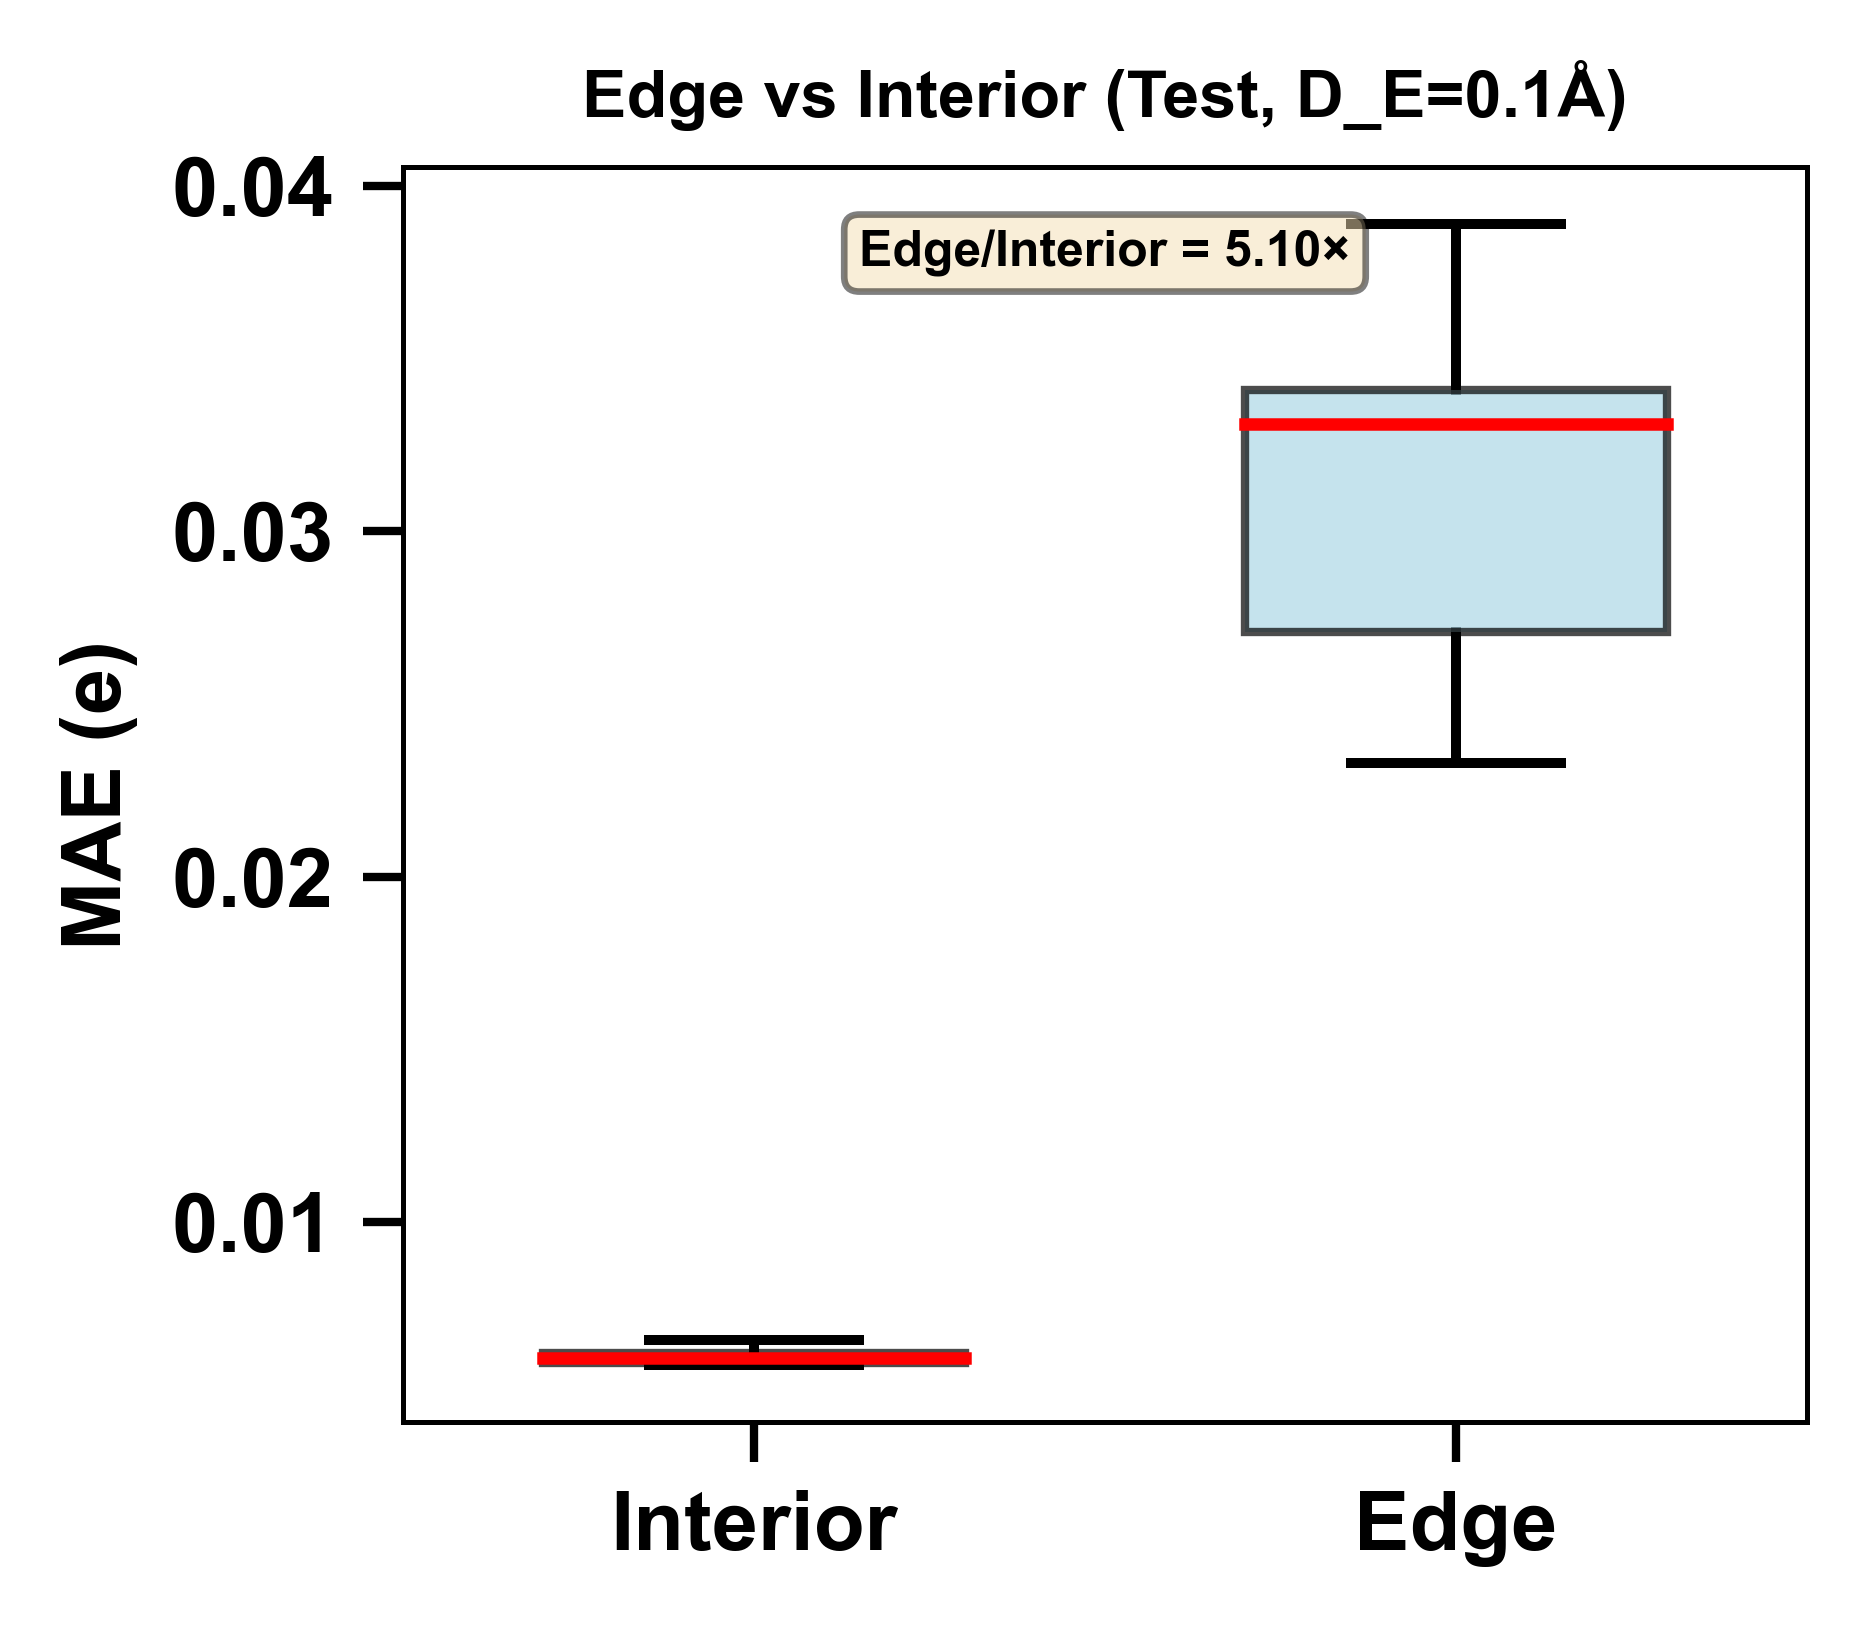

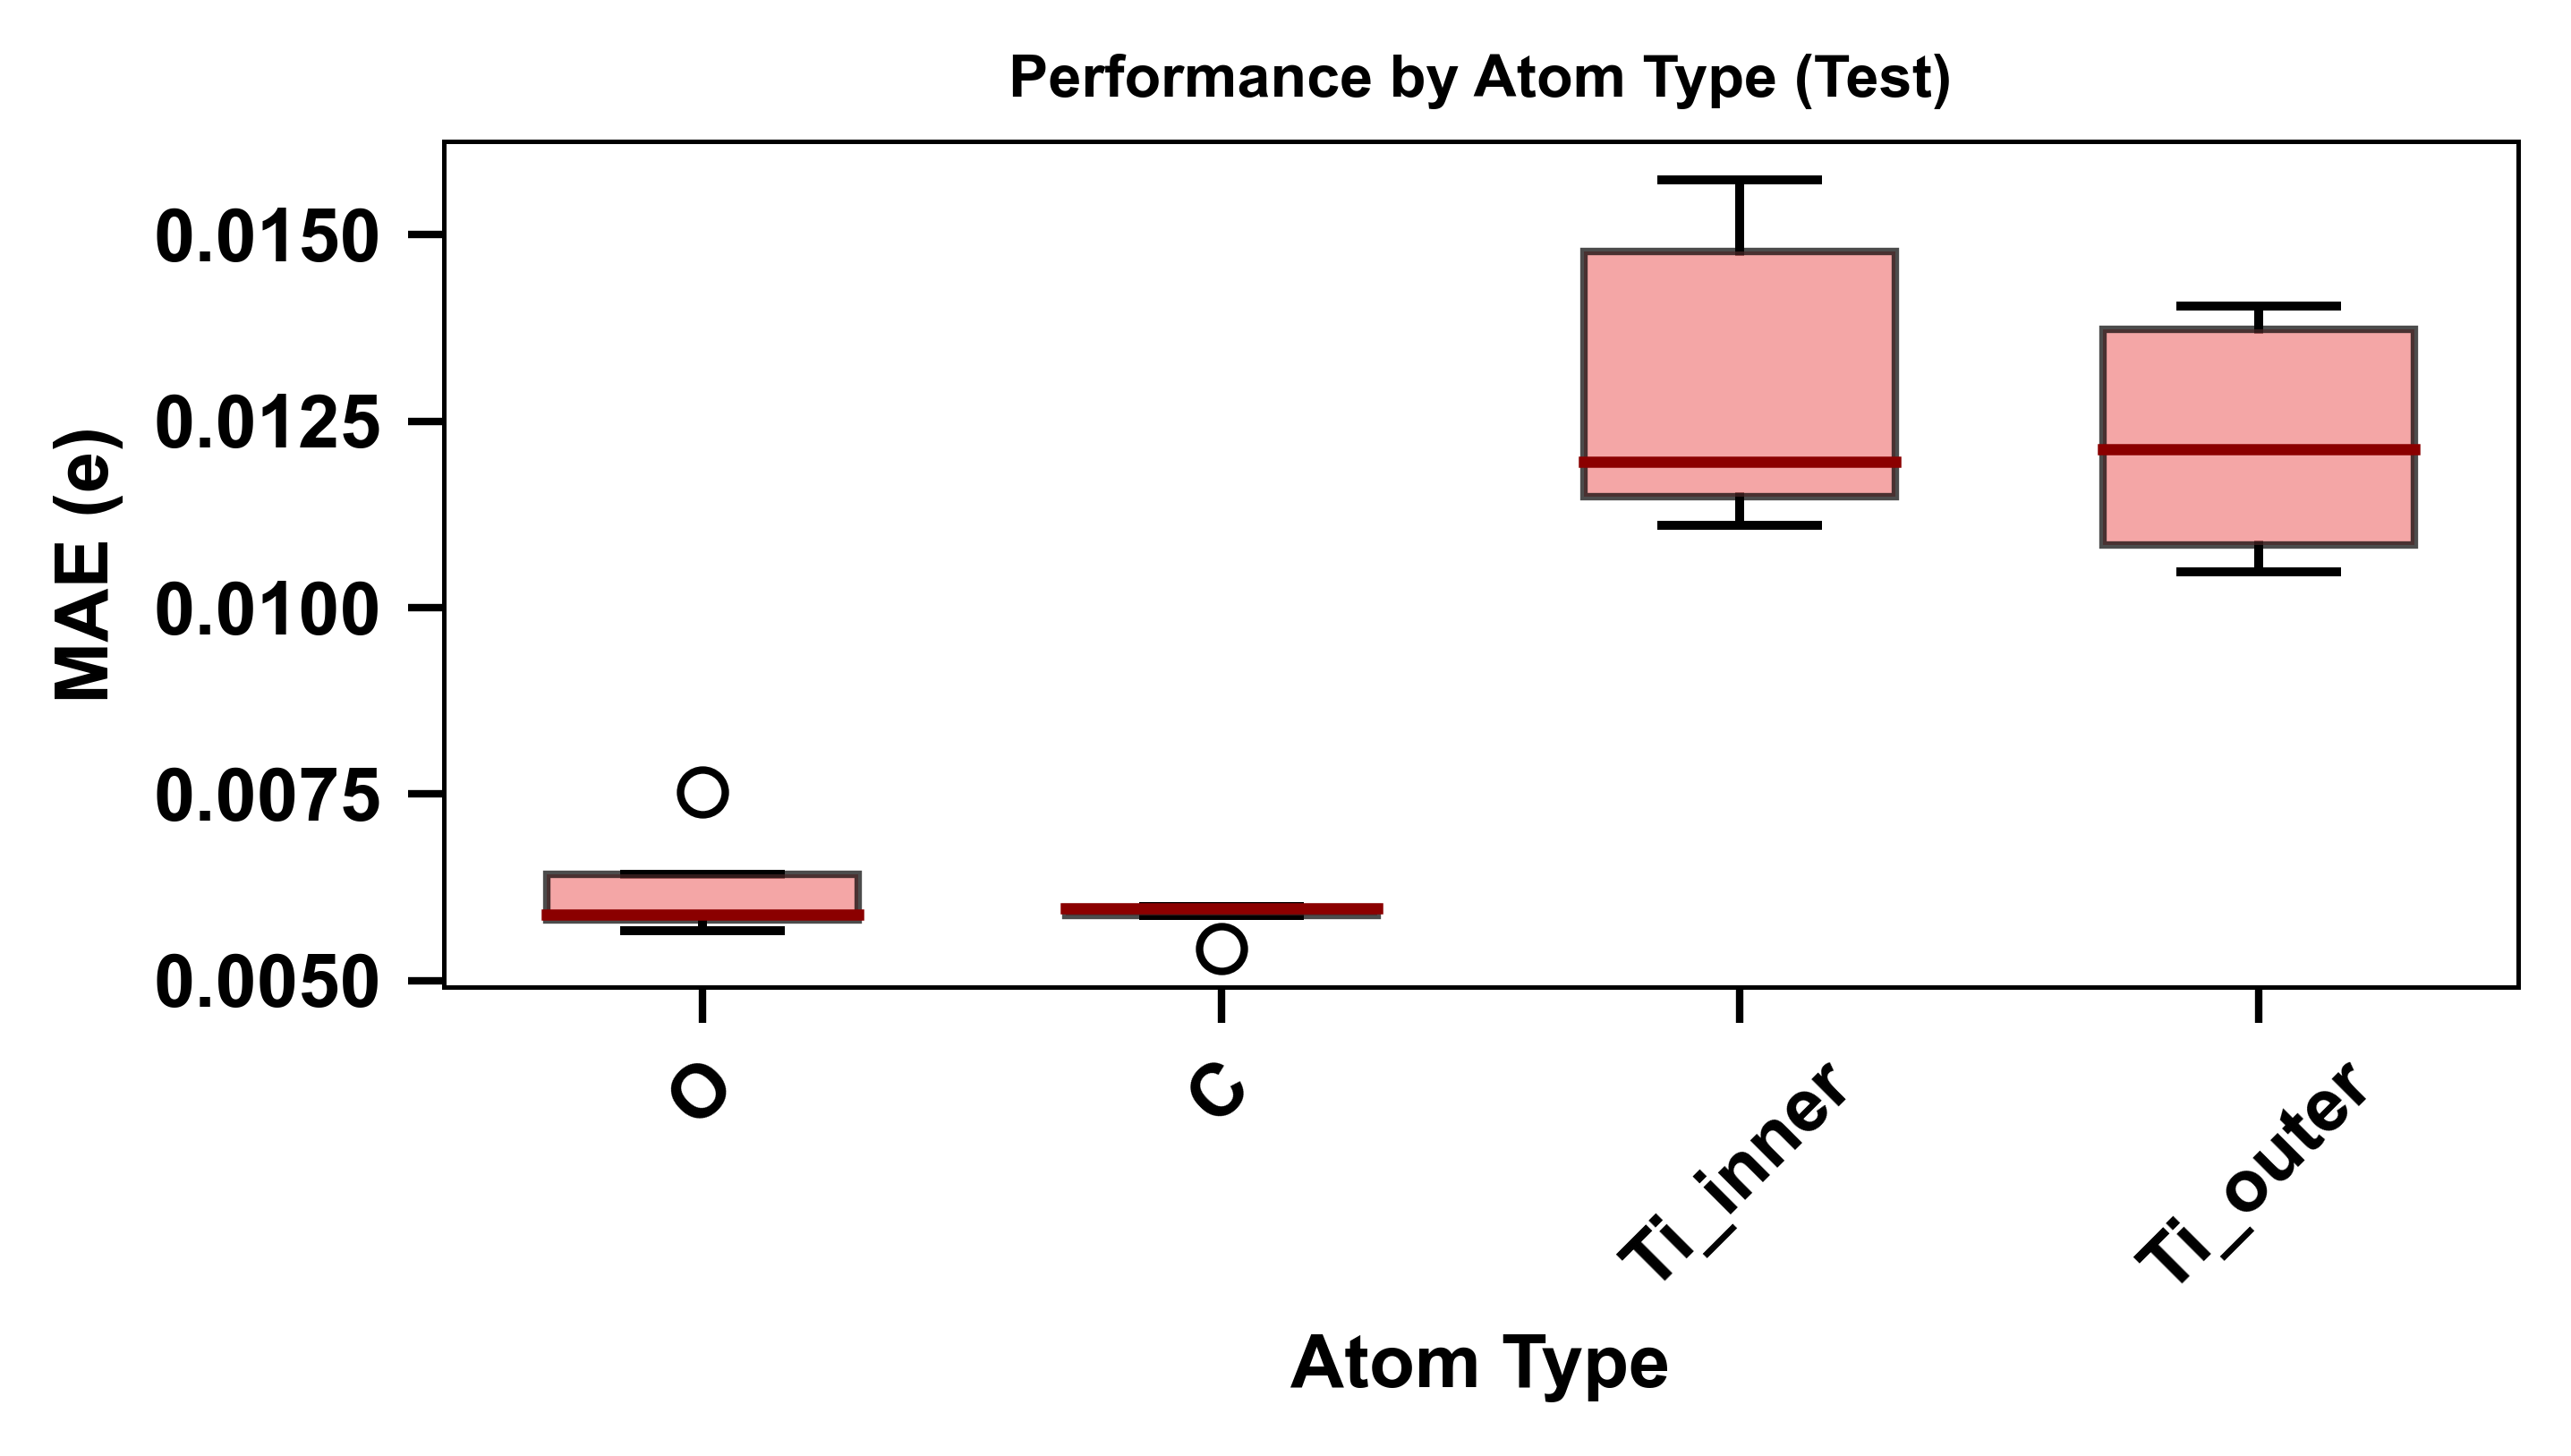

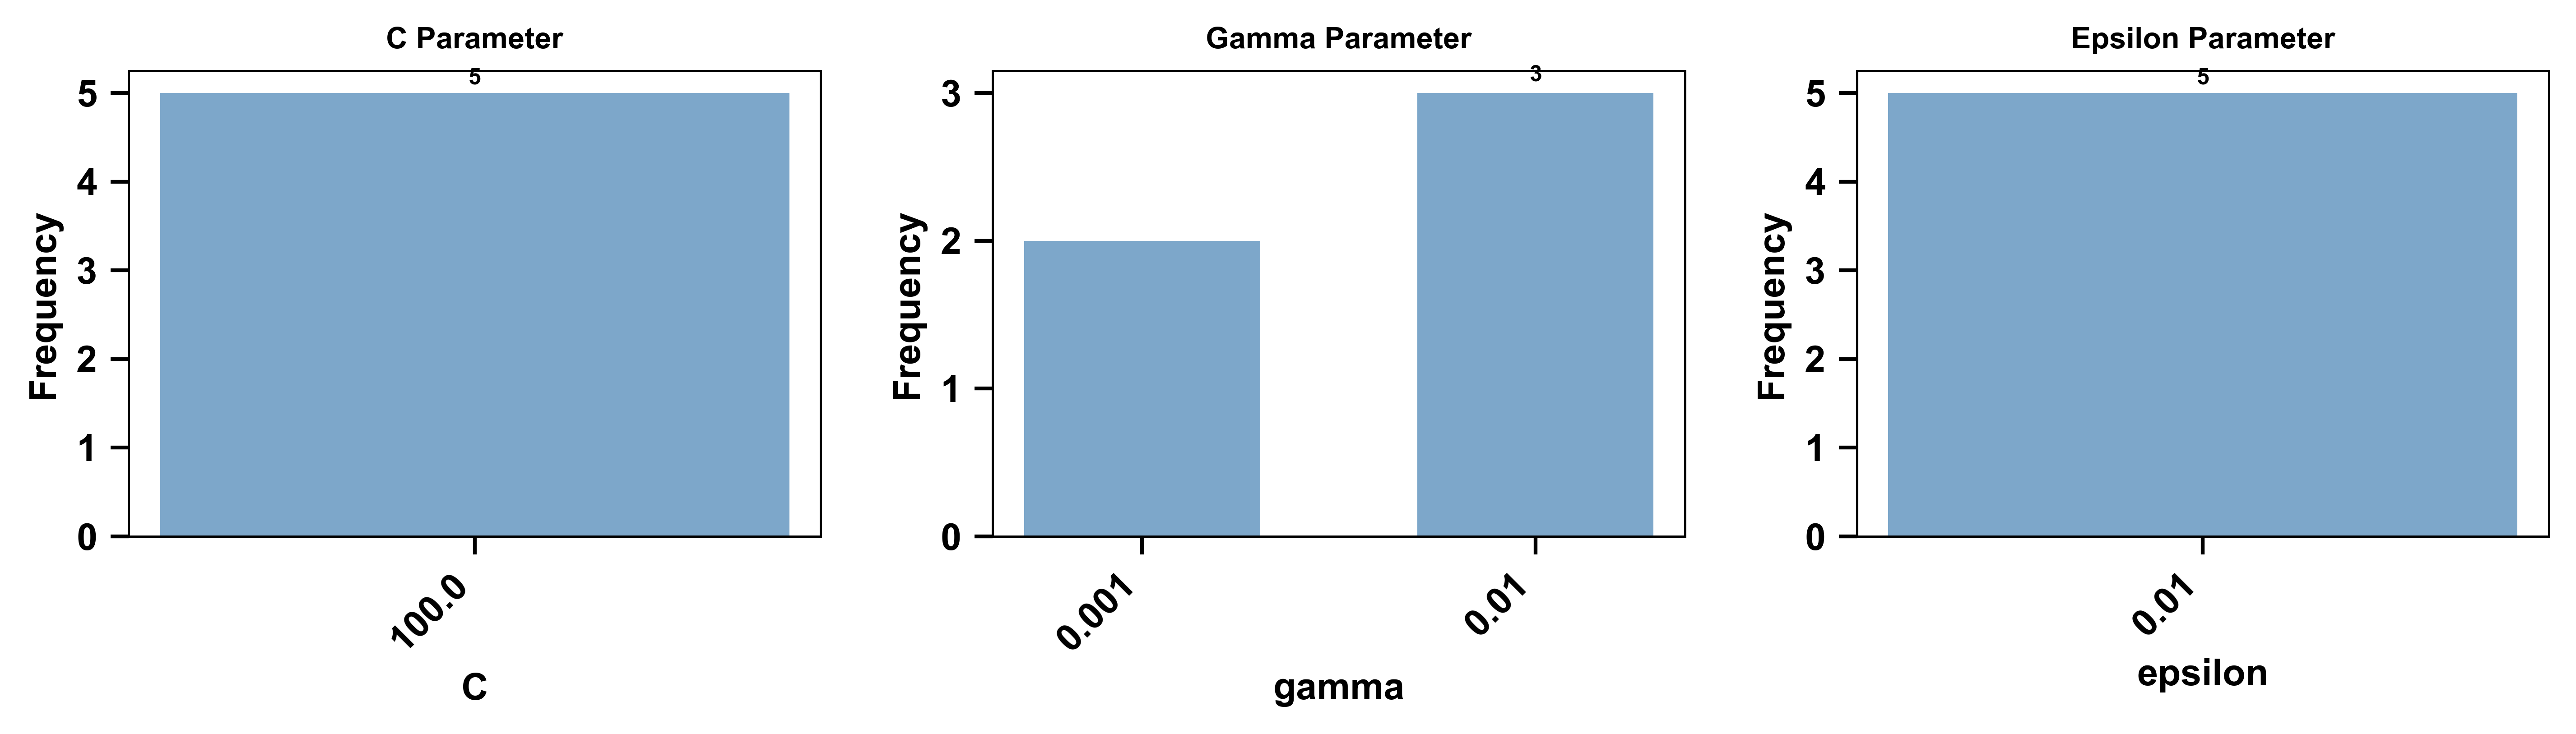

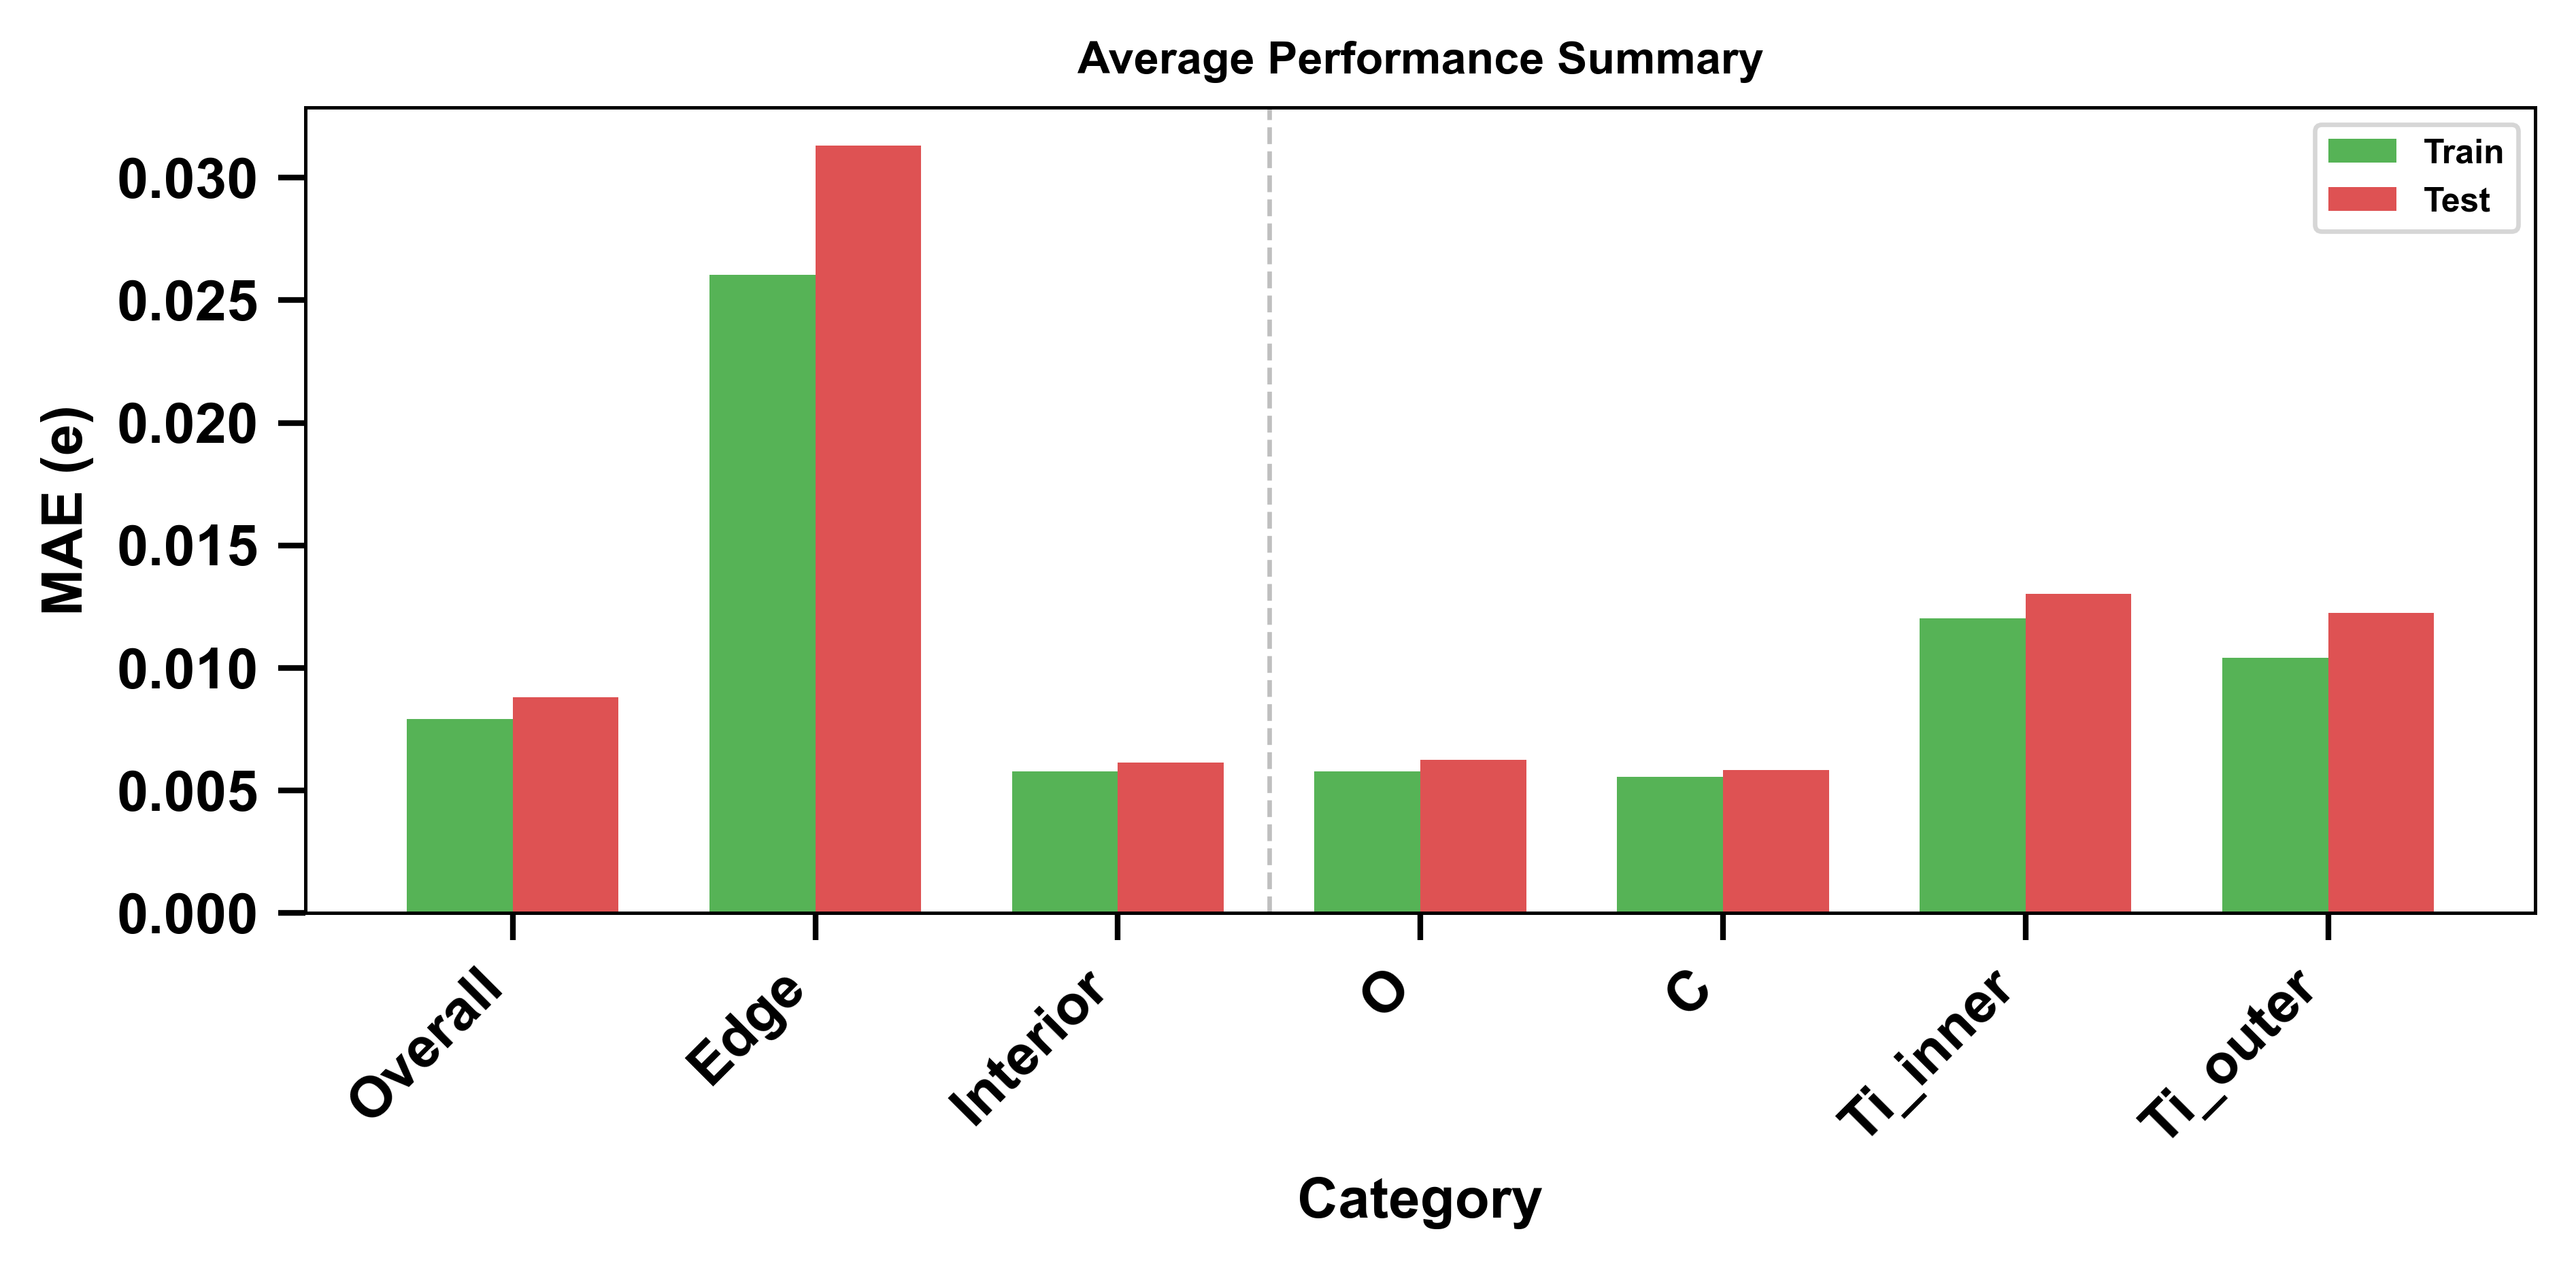

测试集平均性能 (5折CV，校正前):
  overall    - MAE: 0.00882 ± 0.00069  RMSE: 0.01905 ± 0.00318  R²: 0.999428 ± 0.000180
  edge       - MAE: 0.03130 ± 0.00549  RMSE: 0.05258 ± 0.00952  R²: 0.994122 ± 0.001943
  interior   - MAE: 0.00613 ± 0.00026  RMSE: 0.00865 ± 0.00120  R²: 0.999886 ± 0.000034


In [3]:
# =============================================================================
# 边缘vs内部原子，按原子类型对比，平均性能汇总
# =============================================================================

# 边缘vs内部原子MAE箱线图
edge_maes     = df_numeric[(df_numeric['dataset']=='test') &
                            (df_numeric['category']=='edge')]['mae'].values
interior_maes = df_numeric[(df_numeric['dataset']=='test') &
                            (df_numeric['category']=='interior')]['mae'].values

fig, ax = plt.subplots(figsize=(3.2, 2.8))
ax.boxplot([interior_maes, edge_maes], positions=[1, 2],
           labels=['Interior', 'Edge'], widths=0.6, patch_artist=True,
           boxprops=dict(facecolor='lightblue', alpha=0.7),
           medianprops=dict(color='red', linewidth=1.5),
           whiskerprops=dict(linewidth=1.2),
           capprops=dict(linewidth=1.2))

ratio = np.mean(edge_maes) / np.mean(interior_maes)
ax.text(0.5, 0.95, f'Edge/Interior = {ratio:.2f}×',
        transform=ax.transAxes, fontsize=ssss, ha='center', va='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
ax.set_ylabel('MAE (e)', fontsize=ss, weight='bold')
ax.set_title(f'Edge vs Interior (Test, D_E={EDGE_THRESHOLD}Å)', fontsize=sss, weight='bold')

plt.tight_layout()
plt.savefig('figures/model_plots/svr_04_edge_vs_interior.png', dpi=600, bbox_inches='tight')
plt.show()

# 按原子类型MAE箱线图
atom_type_data = df_numeric[(df_numeric['dataset']=='test') &
                             (df_numeric['category']=='atom_type')]
atom_type_maes = {label: atom_type_data[atom_type_data['subcategory']==label]['mae'].values
                  for label in ATOM_TYPE_LABELS}

fig, ax = plt.subplots(figsize=(4.8, 2.8))
ax.boxplot([atom_type_maes[label] for label in ATOM_TYPE_LABELS],
           positions=range(1, len(ATOM_TYPE_LABELS)+1),
           labels=ATOM_TYPE_LABELS, widths=0.6, patch_artist=True,
           boxprops=dict(facecolor='lightcoral', alpha=0.7),
           medianprops=dict(color='darkred', linewidth=1.5),
           whiskerprops=dict(linewidth=1.2),
           capprops=dict(linewidth=1.2))
ax.set_ylabel('MAE (e)', fontsize=ss, weight='bold')
ax.set_xlabel('Atom Type', fontsize=ss, weight='bold')
ax.set_title('Performance by Atom Type (Test)', fontsize=sss, weight='bold')
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('figures/model_plots/svr_05_by_atom_type.png', dpi=600, bbox_inches='tight')
plt.show()

# 超参数选择分布（从 svr_results.json 的 fold_details 中提取）
# fold_details 中 best_params 被序列化为字符串，需还原
import ast
param_dist = {'C': [], 'gamma': [], 'epsilon': []}
for fold_detail in results_dict['fold_details']:
    bp = ast.literal_eval(fold_detail['best_params']) \
         if isinstance(fold_detail['best_params'], str) else fold_detail['best_params']
    for param in param_dist:
        param_dist[param].append(str(bp[param]))

fig, axes = plt.subplots(1, 3, figsize=(9.6, 2.8))
for ax, param, title in zip(axes, ['C', 'gamma', 'epsilon'],
                             ['C Parameter', 'Gamma Parameter', 'Epsilon Parameter']):
    from collections import Counter
    counts = Counter(param_dist[param])
    labels_p = list(counts.keys())
    vals_p   = list(counts.values())

    # 数值型参数按值排序
    if param in ('C', 'epsilon'):
        try:
            sorted_idx = np.argsort([float(l) for l in labels_p])
            labels_p = [labels_p[i] for i in sorted_idx]
            vals_p   = [vals_p[i]   for i in sorted_idx]
        except ValueError:
            pass

    ax.bar(range(len(labels_p)), vals_p, width=0.6, alpha=0.7, color='steelblue')
    ax.set_xticks(range(len(labels_p)))
    ax.set_xticklabels(labels_p, rotation=45, ha='right')
    ax.set_xlabel(param, fontsize=ss, weight='bold')
    ax.set_ylabel('Frequency', fontsize=ss, weight='bold')
    ax.set_title(title, fontsize=sss, weight='bold')

    max_idx = int(np.argmax(vals_p))
    ax.text(max_idx, vals_p[max_idx] + 0.05, str(vals_p[max_idx]),
            ha='center', va='bottom', fontsize=ssss, weight='bold')

plt.tight_layout()
plt.savefig('figures/model_plots/svr_06_param_selection.png', dpi=600, bbox_inches='tight')
plt.show()

# 平均性能汇总柱状图
categories     = ['Overall', 'Edge', 'Interior'] + ATOM_TYPE_LABELS
train_maes_avg = ([train_averaged[c]['mae_mean'] for c in ['overall', 'edge', 'interior']] +
                  [train_averaged['by_atom_type'][l]['mae_mean'] for l in ATOM_TYPE_LABELS])
test_maes_avg  = ([test_averaged[c]['mae_mean']  for c in ['overall', 'edge', 'interior']] +
                  [test_averaged['by_atom_type'][l]['mae_mean']  for l in ATOM_TYPE_LABELS])

fig, ax = plt.subplots(figsize=(6.4, 3.2))
x = np.arange(len(categories))
ax.bar(x - width/2, train_maes_avg, width, label='Train', alpha=0.8, color='tab:green')
ax.bar(x + width/2, test_maes_avg,  width, label='Test',  alpha=0.8, color='tab:red')
ax.axvline(2.5, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
ax.set_xlabel('Category', fontsize=ss, weight='bold')
ax.set_ylabel('MAE (e)', fontsize=ss, weight='bold')
ax.set_title('Average Performance Summary', fontsize=sss, weight='bold')
ax.set_xticks(x)
ax.set_xticklabels(categories, rotation=45, ha='right')
ax.legend(fontsize=ssss)

plt.tight_layout()
plt.savefig('figures/model_plots/svr_07_performance_summary.png', dpi=600, bbox_inches='tight')
plt.show()

print("测试集平均性能 (5折CV，校正前):")
for cat in ['overall', 'edge', 'interior']:
    m = test_averaged[cat]
    print(f"  {cat:10s} - MAE: {m['mae_mean']:.5f} ± {m['mae_std']:.5f}  "
          f"RMSE: {m['rmse_mean']:.5f} ± {m['rmse_std']:.5f}  "
          f"R²: {m['r2_mean']:.6f} ± {m['r2_std']:.6f}")



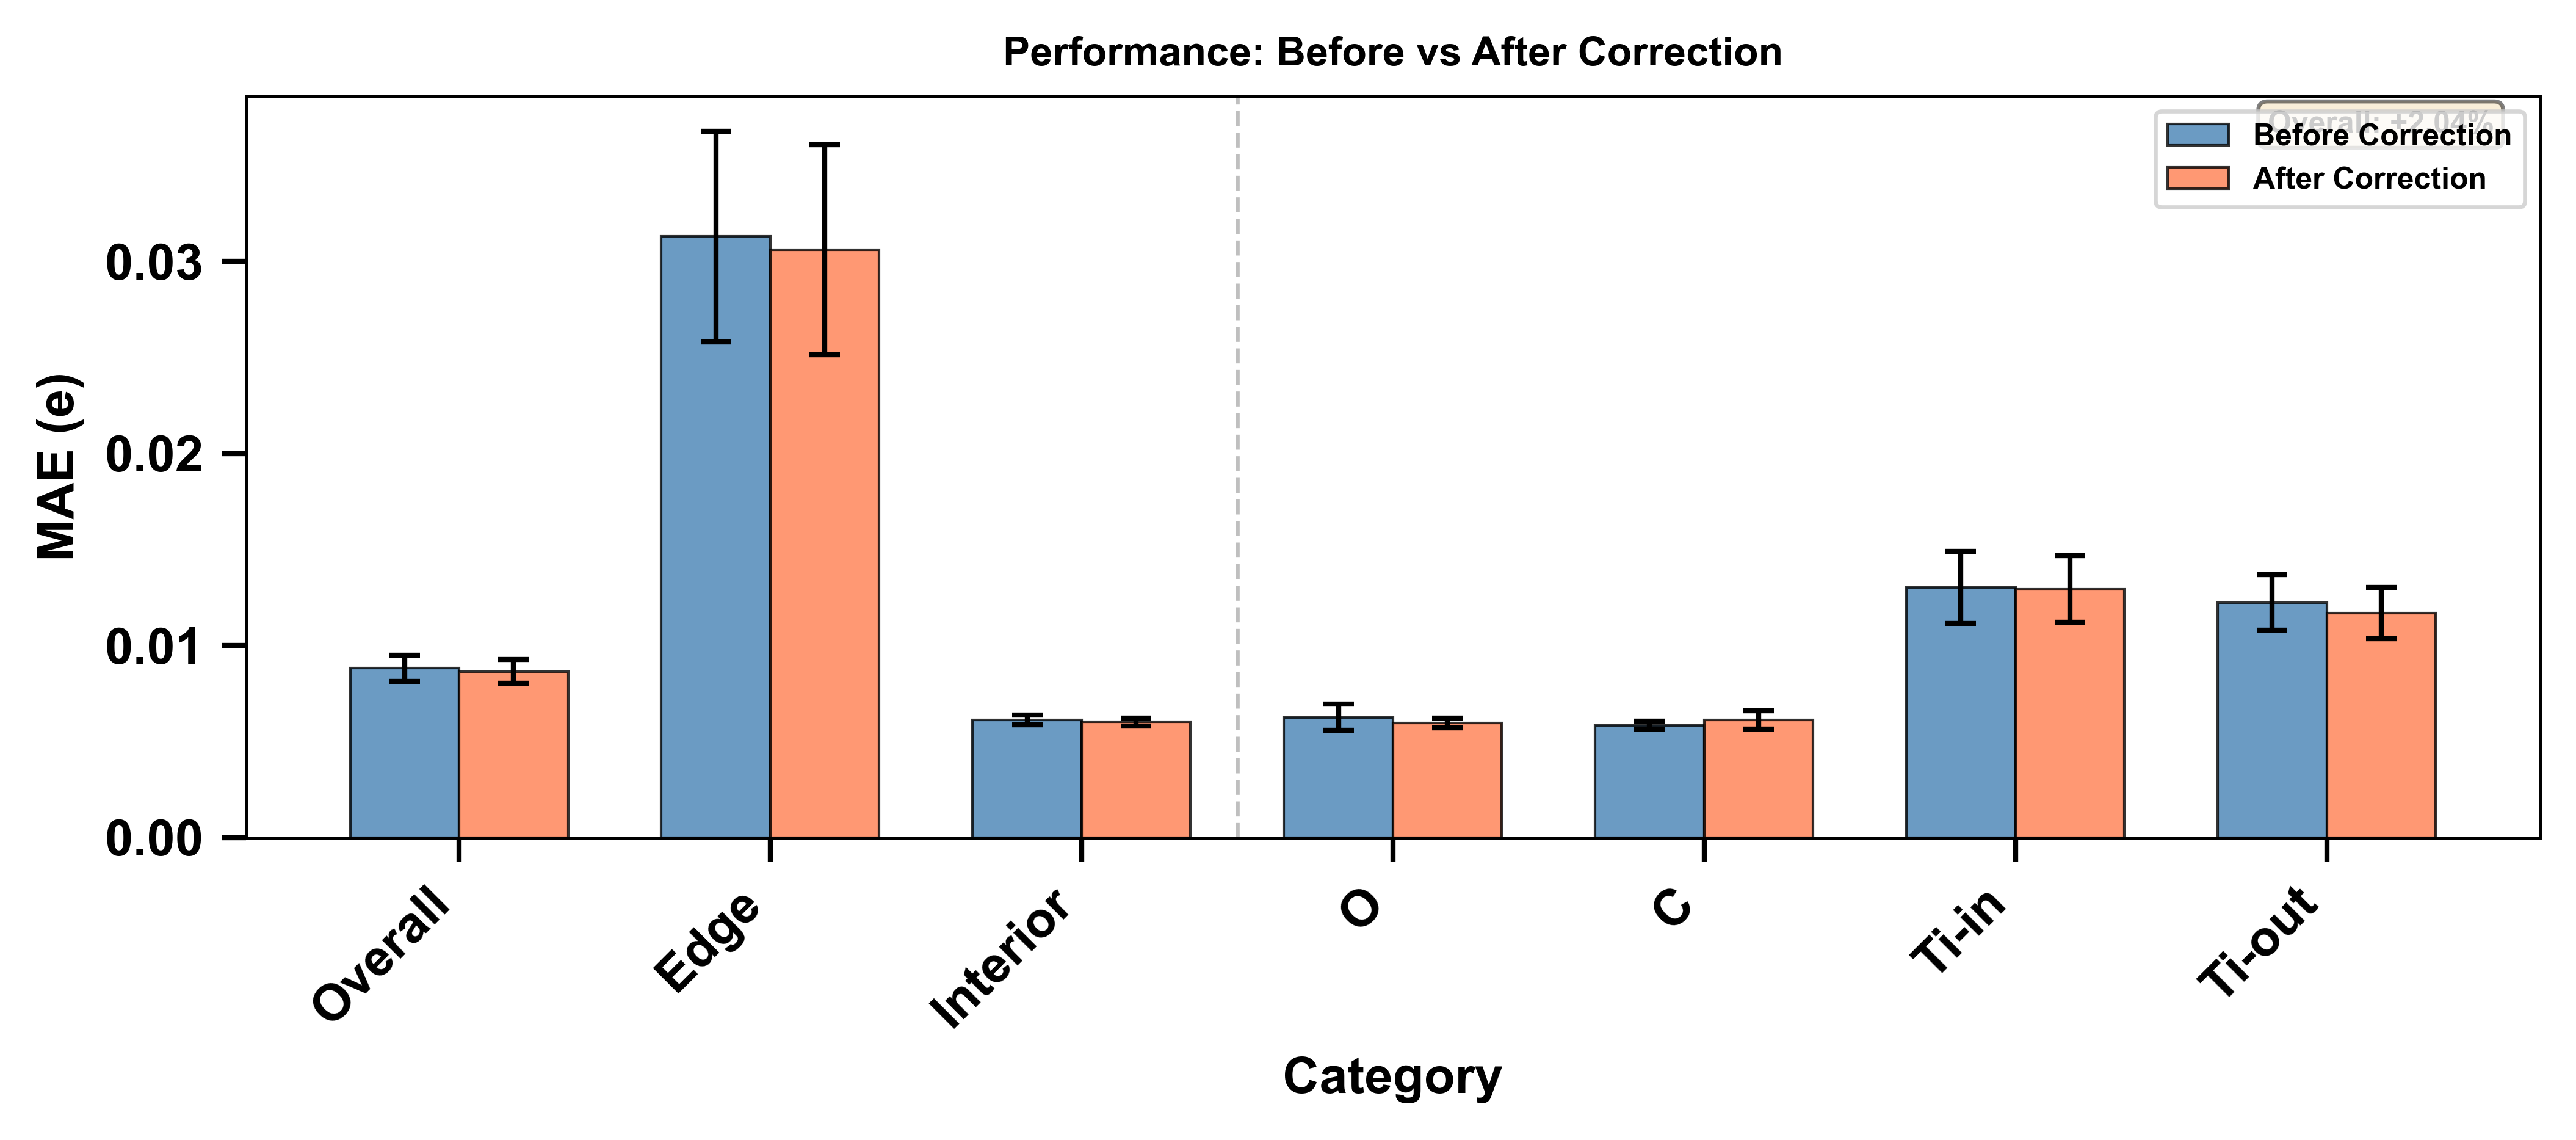

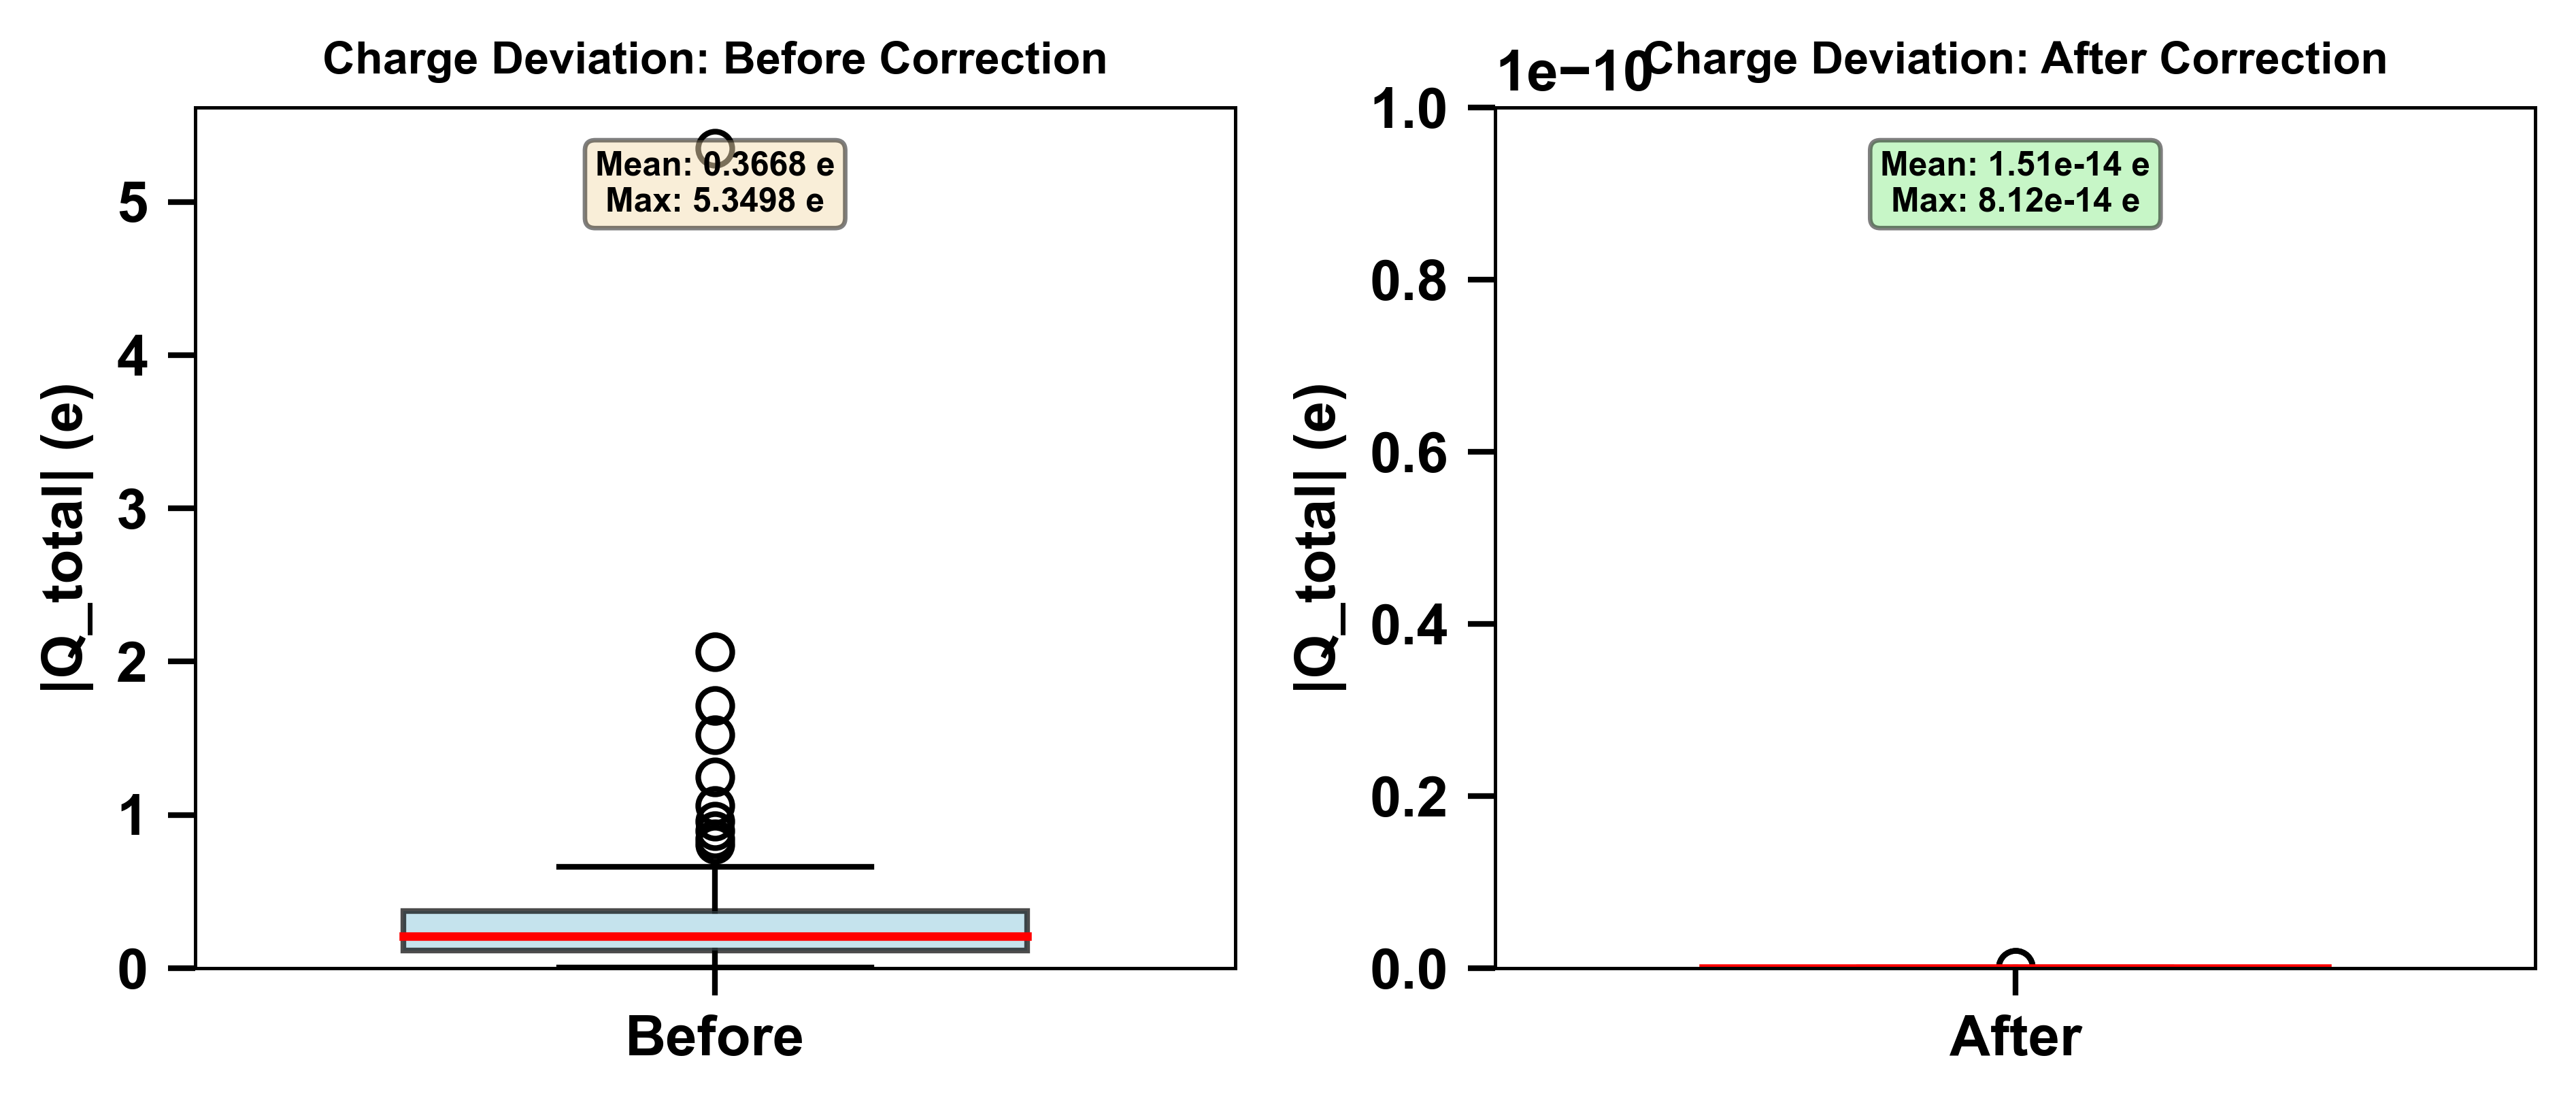

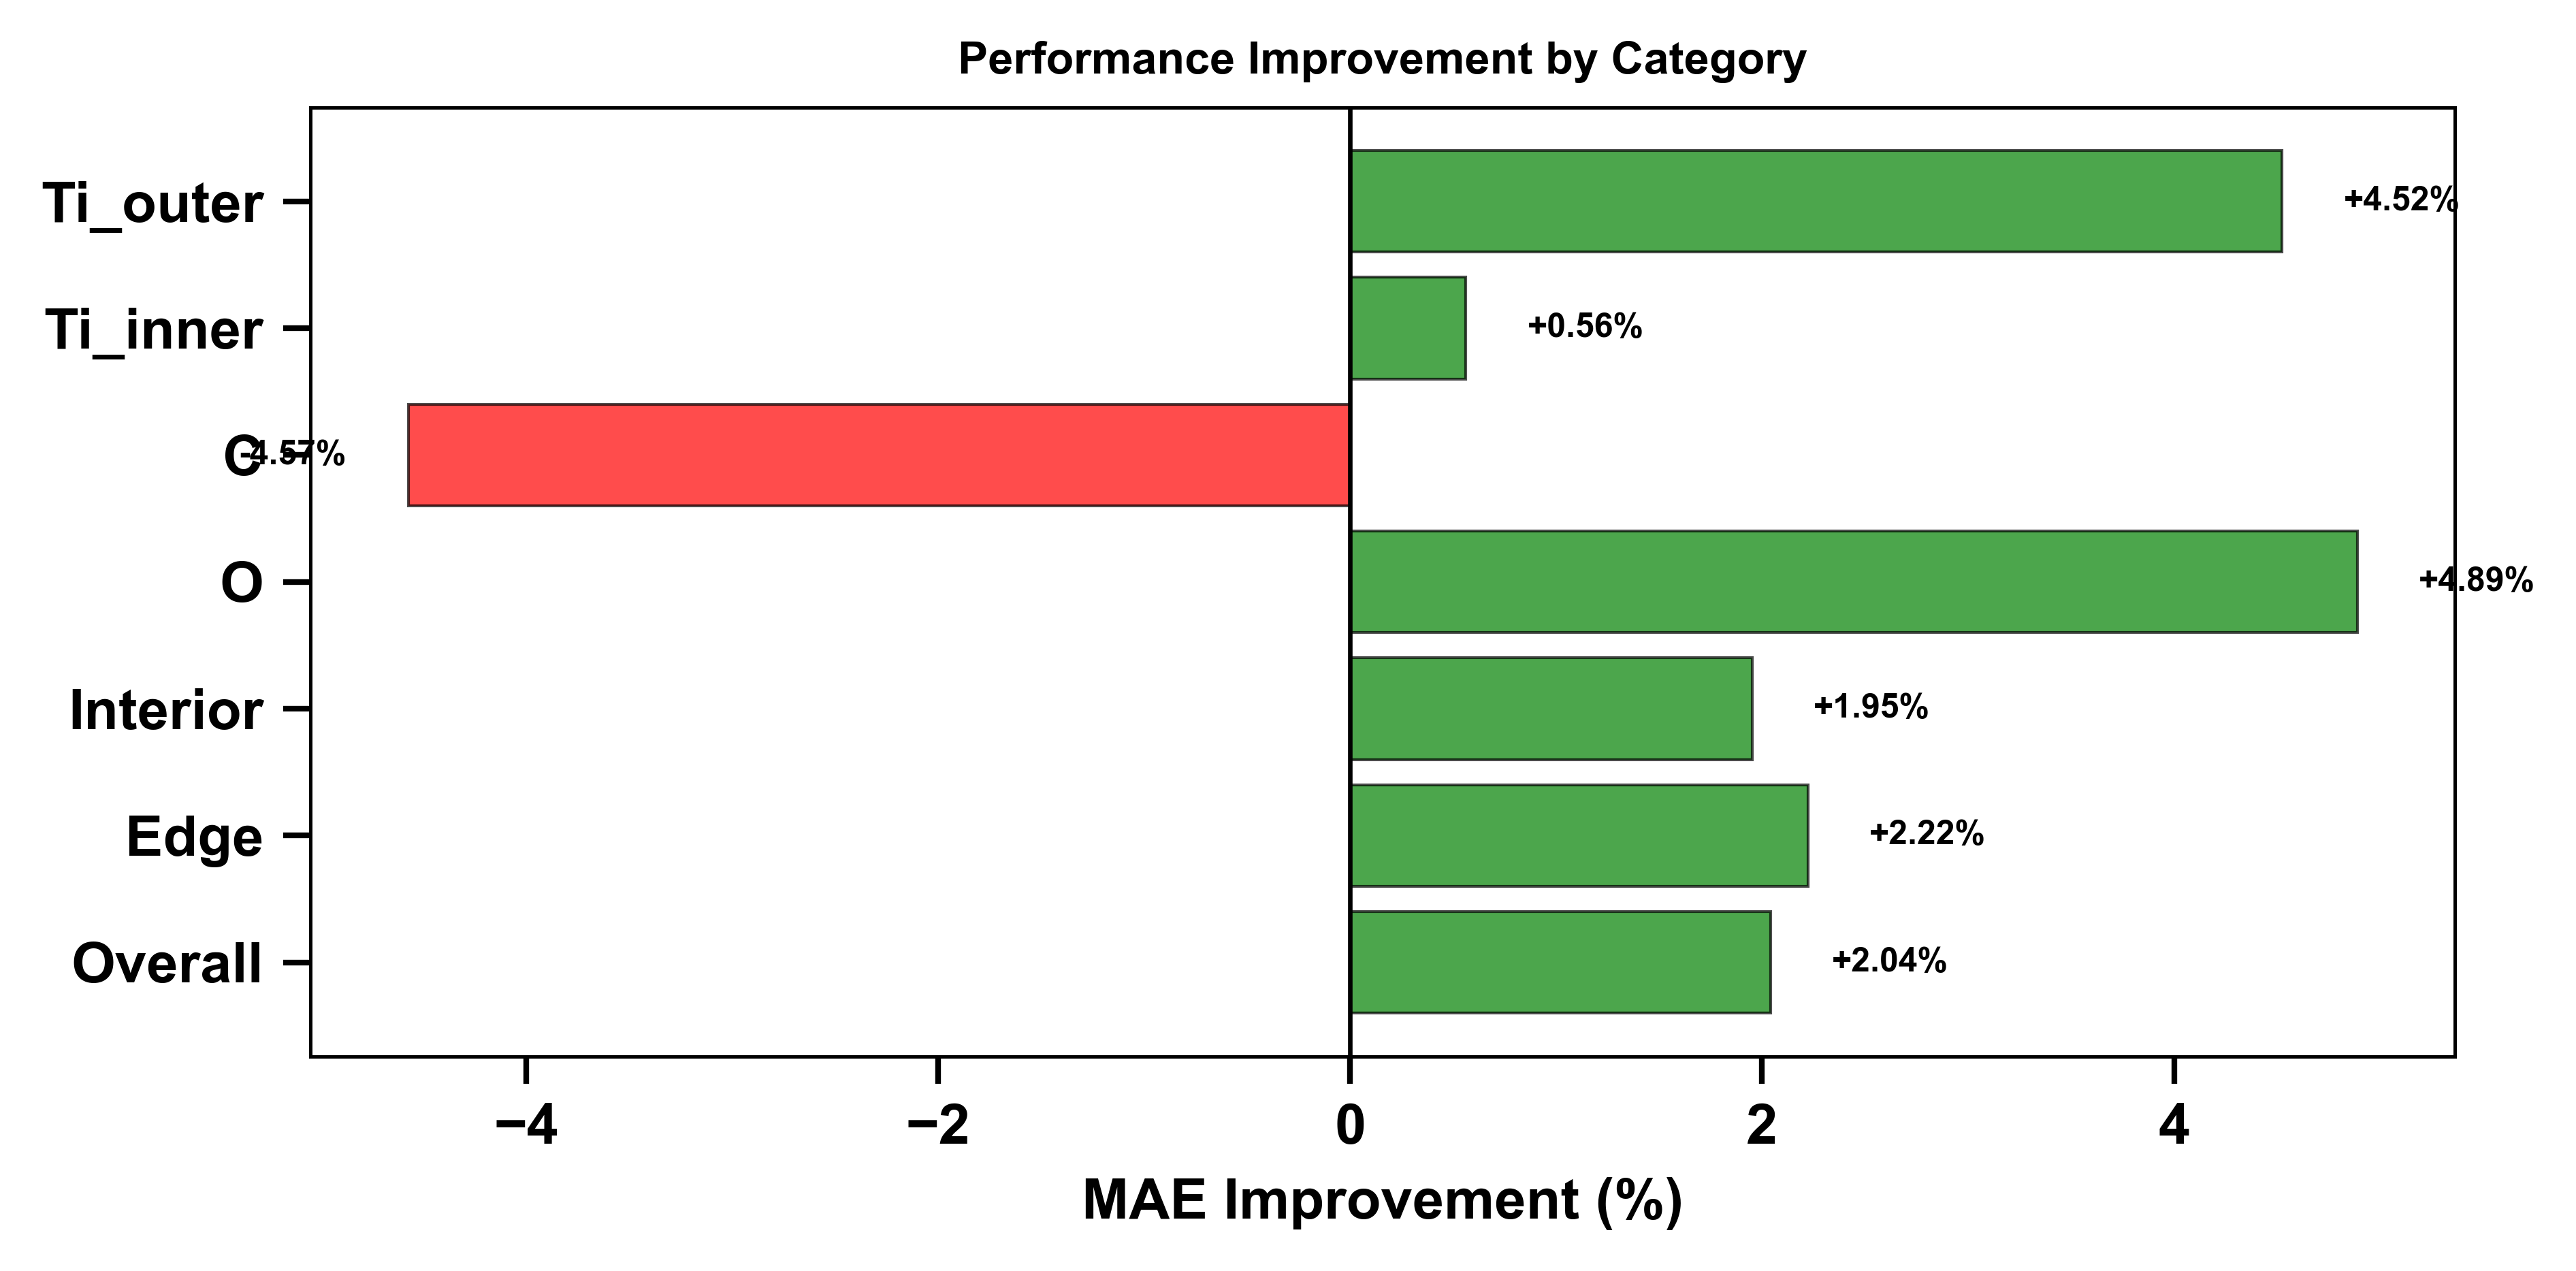

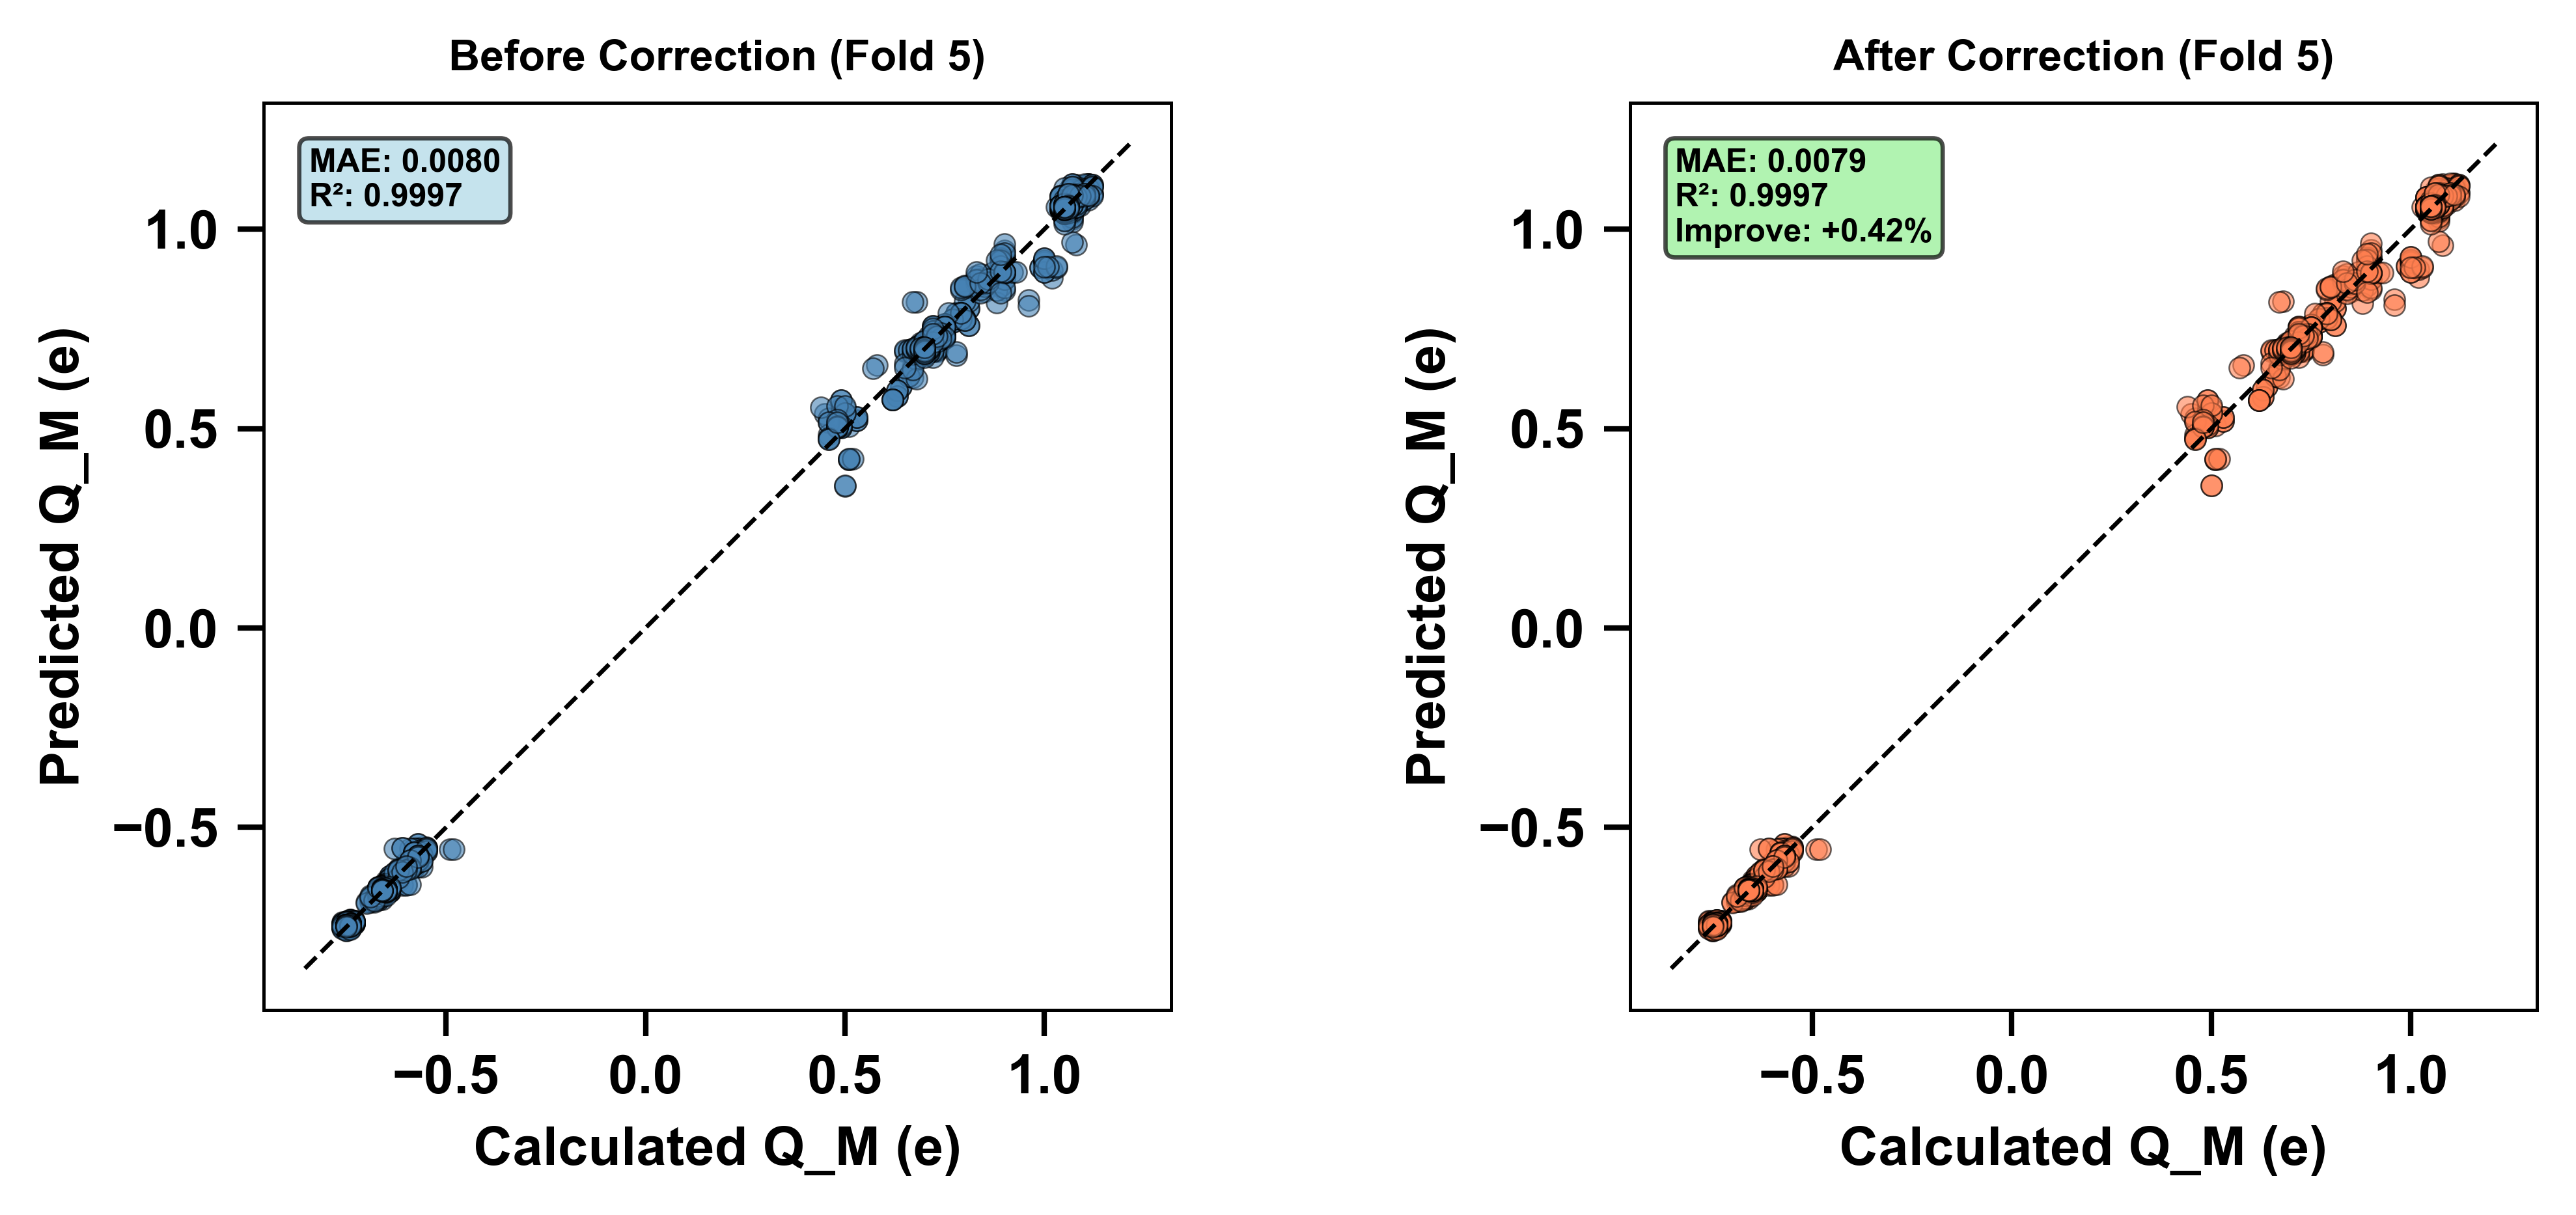

测试集平均性能 (5折CV，校正后):
  overall    - MAE: 0.00864 ± 0.00062  RMSE: 0.01812 ± 0.00285  R²: 0.999484 ± 0.000159
  edge       - MAE: 0.03061 ± 0.00547  RMSE: 0.05005 ± 0.00892  R²: 0.994676 ± 0.001825
  interior   - MAE: 0.00602 ± 0.00022  RMSE: 0.00818 ± 0.00057  R²: 0.999900 ± 0.000015


In [4]:
# =============================================================================
# 电中性校正相关图表
# =============================================================================

# 校正前后性能对比柱状图（带误差棒）
categories_disp = ['Overall', 'Edge', 'Interior'] + ATOM_TYPE_LABELS
cat_labels_disp = ['Overall', 'Edge', 'Interior', 'O', 'C', 'Ti-in', 'Ti-out']

mae_before, mae_std_before, mae_after, mae_std_after = [], [], [], []
for i, cat in enumerate(categories_disp):
    if i < 3:
        row = df_comparison[df_comparison['category'] == cat]
    else:
        row = df_comparison[(df_comparison['category'] == 'Atom_Type') &
                            (df_comparison['subcategory'] == cat)]
    mae_before.append(    row['mae_before'].values[0]    if len(row) > 0 else np.nan)
    mae_std_before.append(row['mae_std_before'].values[0] if len(row) > 0 else np.nan)
    mae_after.append(     row['mae_after'].values[0]     if len(row) > 0 else np.nan)
    mae_std_after.append( row['mae_std_after'].values[0]  if len(row) > 0 else np.nan)

fig, ax = plt.subplots(figsize=(7.2, 3.2))
x = np.arange(len(cat_labels_disp))

ax.bar(x - width/2, mae_before, width, yerr=mae_std_before, capsize=3,
       label='Before Correction', alpha=0.8, color='steelblue',
       edgecolor='black', linewidth=0.5)
ax.bar(x + width/2, mae_after,  width, yerr=mae_std_after,  capsize=3,
       label='After Correction',  alpha=0.8, color='coral',
       edgecolor='black', linewidth=0.5)

ax.axvline(2.5, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
ax.set_xlabel('Category', fontsize=ss, weight='bold')
ax.set_ylabel('MAE (e)', fontsize=ss, weight='bold')
ax.set_title('Performance: Before vs After Correction', fontsize=sss, weight='bold')
ax.set_xticks(x)
ax.set_xticklabels(cat_labels_disp, rotation=45, ha='right')
ax.legend(fontsize=ssss, loc='upper right')

overall_improvement = df_comparison[df_comparison['category']=='Overall']['mae_improvement_percent'].values[0]
ax.text(0.98, 0.98, f'Overall: {overall_improvement:+.2f}%',
        transform=ax.transAxes, fontsize=ssss, ha='right', va='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('figures/model_plots/svr_08_correction_comparison.png', dpi=600, bbox_inches='tight')
plt.show()

# 总电荷偏差分布（校正前后）
test_Q_before = df_test_all.groupby('structure_id')['y_pred'].sum()
test_Q_after  = df_test_all_corrected.groupby('structure_id')['y_pred_corrected'].sum()

fig, axes = plt.subplots(1, 2, figsize=(6.4, 2.8))

axes[0].boxplot([np.abs(test_Q_before)], labels=['Before'], widths=0.6, patch_artist=True,
                boxprops=dict(facecolor='lightblue', alpha=0.7),
                medianprops=dict(color='red', linewidth=1.5))
axes[0].set_ylabel('|Q_total| (e)', fontsize=ss, weight='bold')
axes[0].set_title('Charge Deviation: Before Correction', fontsize=sss, weight='bold')
axes[0].set_ylim(bottom=0)
axes[0].text(0.5, 0.95,
             f'Mean: {np.abs(test_Q_before).mean():.4f} e\nMax: {np.abs(test_Q_before).max():.4f} e',
             transform=axes[0].transAxes, fontsize=ssss, ha='center', va='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

max_after = np.abs(test_Q_after).max()
axes[1].boxplot([np.abs(test_Q_after)], labels=['After'], widths=0.6, patch_artist=True,
                boxprops=dict(facecolor='lightgreen', alpha=0.7),
                medianprops=dict(color='red', linewidth=1.5))
axes[1].set_ylabel('|Q_total| (e)', fontsize=ss, weight='bold')
axes[1].set_title('Charge Deviation: After Correction', fontsize=sss, weight='bold')
axes[1].set_ylim([0, max(max_after * 2, 1e-10)])
axes[1].text(0.5, 0.95,
             f'Mean: {np.abs(test_Q_after).mean():.2e} e\nMax: {max_after:.2e} e',
             transform=axes[1].transAxes, fontsize=ssss, ha='center', va='top',
             bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))

plt.tight_layout()
plt.savefig('figures/model_plots/svr_09_charge_deviation.png', dpi=600, bbox_inches='tight')
plt.show()

# MAE改善率水平柱状图
improvements = df_comparison['mae_improvement_percent'].values
imp_labels   = []
for _, row in df_comparison.iterrows():
    if row['category'] in ('Overall', 'Edge', 'Interior'):
        imp_labels.append(row['category'])
    else:
        imp_labels.append(row['subcategory'])

fig, ax = plt.subplots(figsize=(6.4, 3.2))
colors = ['green' if v > 0 else 'red' for v in improvements]
bars   = ax.barh(range(len(improvements)), improvements,
                 color=colors, alpha=0.7, edgecolor='black', linewidth=0.5)
ax.set_yticks(range(len(improvements)))
ax.set_yticklabels(imp_labels, fontsize=ss)
ax.set_xlabel('MAE Improvement (%)', fontsize=ss, weight='bold')
ax.set_title('Performance Improvement by Category', fontsize=sss, weight='bold')
ax.axvline(0, color='black', linewidth=0.8)

for i, (bar, imp) in enumerate(zip(bars, improvements)):
    ax.text(imp + (0.3 if imp > 0 else -0.3), i, f'{imp:+.2f}%',
            ha='left' if imp > 0 else 'right', va='center', fontsize=ssss, weight='bold')

plt.tight_layout()
plt.savefig('figures/model_plots/svr_10_improvement_rate.png', dpi=600, bbox_inches='tight')
plt.show()

# 校正前后散点图对比（最佳折叠）
df_test_best      = df_test_all[df_test_all['fold'] == best_fold_num]
df_test_best_corr = df_test_all_corrected[df_test_all_corrected['fold'] == best_fold_num]

y_test_true      = df_test_best['y_true'].values
y_test_pred      = df_test_best['y_pred'].values
y_test_pred_corr = df_test_best_corr['y_pred_corrected'].values

mae_b = mean_absolute_error(y_test_true, y_test_pred)
mae_a = mean_absolute_error(y_test_true, y_test_pred_corr)
r2_b  = r2_score(y_test_true, y_test_pred)
r2_a  = r2_score(y_test_true, y_test_pred_corr)

all_vals = np.concatenate([y_test_true, y_test_pred, y_test_pred_corr])
vmin, vmax = all_vals.min(), all_vals.max()
margin = (vmax - vmin) * 0.05

fig, axes = plt.subplots(1, 2, figsize=(7.2, 3.2))

axes[0].scatter(y_test_true, y_test_pred, s=15, color='steelblue',
                alpha=0.6, edgecolors='black', linewidths=0.3)
axes[0].plot([vmin-margin, vmax+margin], [vmin-margin, vmax+margin],
             'k--', linewidth=ref_line_size)
axes[0].set_xlabel('Calculated Q_M (e)', fontsize=ss, weight='bold')
axes[0].set_ylabel('Predicted Q_M (e)', fontsize=ss, weight='bold')
axes[0].set_title(f'Before Correction (Fold {best_fold_num})', fontsize=sss, weight='bold')
axes[0].set_aspect('equal', adjustable='box')
axes[0].text(0.05, 0.95, f'MAE: {mae_b:.4f}\nR²: {r2_b:.4f}',
             transform=axes[0].transAxes, fontsize=ssss, va='top',
             bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7))

axes[1].scatter(y_test_true, y_test_pred_corr, s=15, color='coral',
                alpha=0.6, edgecolors='black', linewidths=0.3)
axes[1].plot([vmin-margin, vmax+margin], [vmin-margin, vmax+margin],
             'k--', linewidth=ref_line_size)
axes[1].set_xlabel('Calculated Q_M (e)', fontsize=ss, weight='bold')
axes[1].set_ylabel('Predicted Q_M (e)', fontsize=ss, weight='bold')
axes[1].set_title(f'After Correction (Fold {best_fold_num})', fontsize=sss, weight='bold')
axes[1].set_aspect('equal', adjustable='box')
axes[1].text(0.05, 0.95,
             f'MAE: {mae_a:.4f}\nR²: {r2_a:.4f}\nImprove: {(mae_b-mae_a)/mae_b*100:+.2f}%',
             transform=axes[1].transAxes, fontsize=ssss, va='top',
             bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.7))

plt.tight_layout()
plt.savefig('figures/model_plots/svr_11_scatter_comparison.png', dpi=600, bbox_inches='tight')
plt.show()

print("测试集平均性能 (5折CV，校正后):")
test_averaged_corrected = results_dict['cv_results_corrected']['test']
for cat in ['overall', 'edge', 'interior']:
    m = test_averaged_corrected[cat]
    print(f"  {cat:10s} - MAE: {m['mae_mean']:.5f} ± {m['mae_std']:.5f}  "
          f"RMSE: {m['rmse_mean']:.5f} ± {m['rmse_std']:.5f}  "
          f"R²: {m['r2_mean']:.6f} ± {m['r2_std']:.6f}")